# jiku-data datasets

This notebook applies the registration methods of `registration1d` to every one-dimensional
dataset distributed with [jiku-data](https://pypi.org/project/jiku-data/) (`pip install jiku-data`;
GPLv3), i.e. all datasets with `dim == 1`, and uses each dataset to raise implications for two
open development questions:

1. **Automated or semi-automated parameter tuning** — which quantities could be estimated from
   the data to choose method parameters (or the method itself), and where such automation is
   *not* possible because the choice depends on the research question.
2. **Experimental design** — each dataset carries a design description (`dataset.params.testname`,
   `dataset.design`). Whether design information (groups, pairing, repeated measures, covariates)
   should enter the registration stage, and how it would interact with the subsequent analysis,
   is discussed but *not* implemented here: every registration below is design-blind.

Each dataset has its own level-2 section. Implications are reported only where a dataset raises
something not already raised by an earlier dataset; the many simulated `SPM1D_ANOVA*` datasets
therefore mostly refer back to the first of their kind.

### What each figure shows

The figure for each dataset has the layout of the comparison figure in notebook 2: the linearly
registered data (`linear only`) and the same data after each method, coloured by the design's
first factor (or by quartile of a continuous covariate). Settings are the package defaults,
except that iteration counts are reduced for datasets with more than 40 observations (marked
`fast` in the title) to keep the total run time reasonable, and pairwise synchronisation
(O(J²) alignments) is run only for J ≤ 20. Multivariate datasets are shown through their first
component: the univariate methods are run on that component alone, whereas the SRSF panel is
the *joint* (vector-SRSF) registration of all components. Landmark registration uses the
automatic global-minimum / global-maximum landmarks and is marked "not applicable" where an
extremum falls on the domain boundary.

The affine panel uses `cover=True` with edge fill (the zero fill of notebook 2 is specific to
data that start and end at zero, such as ground reaction forces).

Below every figure a short table reports, for each method, the residual sum of squares about the
cross-sectional mean relative to the linearly registered data (`SSE ratio`), the largest
displacement (`max |disp|`, fraction of the domain) and the run time. The SSE ratio is a
descriptive quantity only: as the featureless datasets below show, a flexible warp reduces it on
pure noise, so a small ratio is not evidence of a successful registration.

In [1]:
import sys, os, time, warnings, textwrap
sys.path.insert(0, os.path.abspath('../src'))   # so that this notebook finds registration1d without installation
import numpy as np
from matplotlib import pyplot as plt
import registration1d as reg1d
import jikudata as jd
warnings.filterwarnings('ignore')
print('registration1d', reg1d.__version__, '| jiku-data', jd.__version__)

COLORS = ['k', 'b', 'g', 'r', 'c', 'm', 'y', 'orange']

def load(name):
    """Return (y, group, group_label, dataset) with y a (J,Q) or (J,Q,D) float array."""
    d = getattr(jd, name)()
    y = np.asarray(d.y, dtype=float)
    x = np.asarray(d.x)
    J = y.shape[0]
    if x.ndim == 0:
        g, lab = np.zeros(J, int), 'single group'
    elif x.ndim == 2:
        g, lab = np.unique(x[:, 0], return_inverse=True)[1], 'factor A'
    elif np.issubdtype(x.dtype, np.floating) and np.unique(x).size > 8:
        g, lab = np.digitize(x, np.quantile(x, [.25, .5, .75])), 'covariate quartile'
    else:
        g, lab = np.unique(x, return_inverse=True)[1], 'group'
    return y, g, lab, d

def run_all(y):
    """Run every method; returns an ordered dict name -> (result or exception, seconds)."""
    J    = y.shape[0]
    y1   = y[:, :, 0] if y.ndim == 3 else y
    fast = J > 40
    mi   = 2 if fast else 5
    nb   = 4 if fast else 6
    out  = {}
    def run(name, fn):
        t0 = time.time()
        try:
            r = fn()
        except Exception as e:
            r = e
        out[name] = (r, time.time() - t0)
    out['linear only'] = (None, 0.0)
    run('affine (cover)',          lambda: reg1d.register_affine(y1, cover=True, fill_value='edge', max_iter=mi))
    run('landmark (min, max)',     lambda: reg1d.register_landmark(y1, kinds=('min', 'max')))
    run('derivative DTW, smoothed',lambda: reg1d.register_dtw(y1, derivative=True, step_pattern='strict', smooth=0.03, max_iter=min(mi, 3)))
    run('continuous',              lambda: reg1d.register_continuous(y1, n_basis=nb, max_iter=mi))
    run('self-modelling',          lambda: reg1d.register_sim(y1, n_basis=nb, max_iter=mi))
    if J <= 20:
        run('pairwise (SRSF engine)', lambda: reg1d.register_pairwise(y1))
    else:
        run('SRSF, lam=0',         lambda: reg1d.register_srsf(y1, max_iter=5, lam=0, parallel=fast))
    run('SRSF' + (' (joint, multivariate)' if y.ndim == 3 else ''), lambda: reg1d.register_srsf(y, max_iter=5, parallel=fast))
    return out, fast

def show(name, y, g, lab, out, fast, d):
    y1  = y[:, :, 0] if y.ndim == 3 else y
    ug  = np.unique(g)
    fig, AX = plt.subplots(2, 4, figsize=(16, 7))
    sse0 = ((y1 - y1.mean(axis=0))**2).sum()
    rows = []
    for ax, (mname, (r, sec)) in zip(AX.ravel(), out.items()):
        if isinstance(r, Exception):
            ax.text(0.5, 0.5, 'not applicable:\n' + textwrap.fill(str(r), 38), ha='center', va='center', transform=ax.transAxes, size=8)
            ax.set_title(mname, size=10); ax.set_xticks([]); ax.set_yticks([])
            rows.append((mname, None, None, sec)); continue
        yy = y1 if r is None else (r.y[:, :, 0] if r.y.ndim == 3 else r.y)
        reg1d.plot.plot_curves(yy, group=g, ax=ax, colors=COLORS, x='percent', legend=(r is None and ug.size > 1),
                               labels=[f'{lab} {u}' for u in ug] if ug.size > 1 else None, lw=0.7)
        ax.set_title(mname, size=10); ax.set_xlabel('domain (%)')
        sse = ((yy - yy.mean(axis=0))**2).sum()
        md_ = 0.0 if r is None else float(np.abs(r.warps.displacement()).max())
        rows.append((mname, sse / sse0, md_, sec))
    AX[0, 0].set_ylabel(name)
    fig.suptitle(f"{name}  (J={y.shape[0]}, Q={y.shape[1]}" + (f", D={y.shape[2]}" if y.ndim == 3 else '') +
                 f"; design: {d.design}, test: {d.params.testname}" + ('; fast settings' if fast else '') + ')', size=12)
    plt.tight_layout(); plt.show()
    print(f"{'method':28s} {'SSE ratio':>10s} {'max |disp|':>11s} {'seconds':>8s}")
    for mname, ratio, md_, sec in rows:
        print(f"{mname:28s} {'-' if ratio is None else f'{ratio:10.3f}':>10s} {'-' if md_ is None else f'{md_:11.3f}':>11s} {sec:8.1f}")

def analyse(name):
    y, g, lab, d = load(name)
    out, fast = run_all(y)
    show(name, y, g, lab, out, fast, d)
    return y, g, out

registration1d 0.0.2 | jiku-data 0.1.10


### Datasets

`Besier2009muscleforces`, `Dorn2012`, `Dorn2012manova`, `Neptune1999kneekin`, `Pataky2014cop`, `PlantarArchAngle`, `Random`, `SPM1D_ANOVA2NESTED_2x2`, `SPM1D_ANOVA2NESTED_2x3`, `SPM1D_ANOVA2NESTED_3x3`, `SPM1D_ANOVA2NESTED_3x4`, `SPM1D_ANOVA2NESTED_3x5`, `SPM1D_ANOVA2NESTED_4x4`, `SPM1D_ANOVA2NESTED_4x5`, `SPM1D_ANOVA2ONERM_2x2`, `SPM1D_ANOVA2ONERM_2x3`, `SPM1D_ANOVA2ONERM_3x3`, `SPM1D_ANOVA2ONERM_3x4`, `SPM1D_ANOVA2ONERM_3x5`, `SPM1D_ANOVA2ONERM_4x4`, `SPM1D_ANOVA2ONERM_4x5`, `SPM1D_ANOVA2RM_2x2`, `SPM1D_ANOVA2RM_2x3`, `SPM1D_ANOVA2RM_3x3`, `SPM1D_ANOVA2RM_3x4`, `SPM1D_ANOVA2RM_3x5`, `SPM1D_ANOVA2RM_4x4`, `SPM1D_ANOVA2RM_4x5`, `SPM1D_ANOVA2_2x2`, `SPM1D_ANOVA2_2x3`, `SPM1D_ANOVA2_3x3`, `SPM1D_ANOVA2_3x4`, `SPM1D_ANOVA2_3x5`, `SPM1D_ANOVA2_4x4`, `SPM1D_ANOVA2_4x5`, `SPM1D_ANOVA3NESTED_2x2x2`, `SPM1D_ANOVA3NESTED_2x4x2`, `SPM1D_ANOVA3ONERM_2x2x2`, `SPM1D_ANOVA3ONERM_2x3x4`, `SPM1D_ANOVA3RM_2x2x2`, `SPM1D_ANOVA3RM_2x3x4`, `SPM1D_ANOVA3TWORM_2x2x2`, `SPM1D_ANOVA3TWORM_2x3x4`, `SPM1D_ANOVA3_2x2x2`, `SPM1D_ANOVA3_2x3x4`, `SimulatedPataky2015a`, `SimulatedPataky2015b`, `SimulatedPataky2015c`, `SimulatedTwoLocalMax`, `SmallSampleLargePosNegEffects`, `SpeedGRF`, `SpeedGRFcategorical`, `SpeedGRFcategoricalRM`, `Weather`

## Besier2009muscleforces

Ten knee-muscle forces during walking (D = 10), patellofemoral-pain patients versus controls
(two-sample Hotelling's T²). The forces span two orders of magnitude between muscles.

**Auto-tuning.** The joint (vector-SRSF) registration is dominated by the components with the
largest slopes, so with unequal scales the warps effectively register the two or three largest
muscles and ignore the rest. A data-driven default is to standardise each component (divide by
its pooled standard deviation, or by its median total variation) before computing the vector SRSF,
and to expose the per-component weights so that a user can favour the components that carry the
timing information. Whether equal weighting is *right* is a modelling choice, so the sensible
automation is "standardise by default, report the effective weight of each component" rather than
a hidden optimisation.

**Design.** With two groups and a pooled template, group differences in timing are absorbed by
the warps and removed from the registered amplitudes; with group-specific templates they would
instead remain in the amplitudes and vanish from the warps. Neither is neutral: the choice decides
which downstream test (amplitude or timing) can detect a group timing effect, so a design-aware
registration must be paired with a matching test rather than added silently.

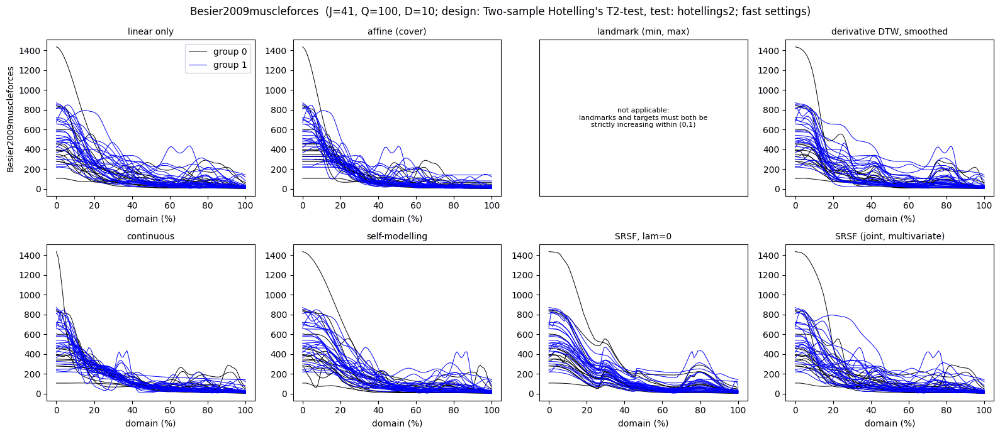

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.609       0.400      1.1
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.990       0.307      1.6
continuous                        0.466       0.481      5.4
self-modelling                    1.028       0.525      9.5
SRSF, lam=0                       0.996       0.336      6.6
SRSF (joint, multivariate)        1.127       0.142     25.1


In [2]:
y, g, out = analyse('Besier2009muscleforces')

## Dorn2012

Three-component ground reaction forces during running at four speeds (canonical correlation
analysis against speed). This is the development dataset of notebooks 1-4; see those for the
detailed findings (amplitude scaling across speeds, the double braking dip, real-time
registration, the multivariate compromise between components).

**Auto-tuning.** The `lam='auto'` default (median total variation) was derived on these data and
on simulated datasets A/B; the panel shows that it leaves the alignment essentially unchanged
relative to `lam=0` here. Speed-dependent stance duration is the case for which real-time
registration (`t='fs=...'`) rather than normalised time should be offered automatically whenever
the input is ragged.

**Design.** With a continuous covariate (speed) the natural downstream analysis is a regression of
displacement fields on speed. A design-aware alternative is to register to a *speed-conditional*
template (a smooth function of speed) rather than to the grand Karcher mean; that would remove the
speed trend in timing from the warps and put it into the template, which is appropriate only if
the timing trend is a nuisance rather than the effect of interest.

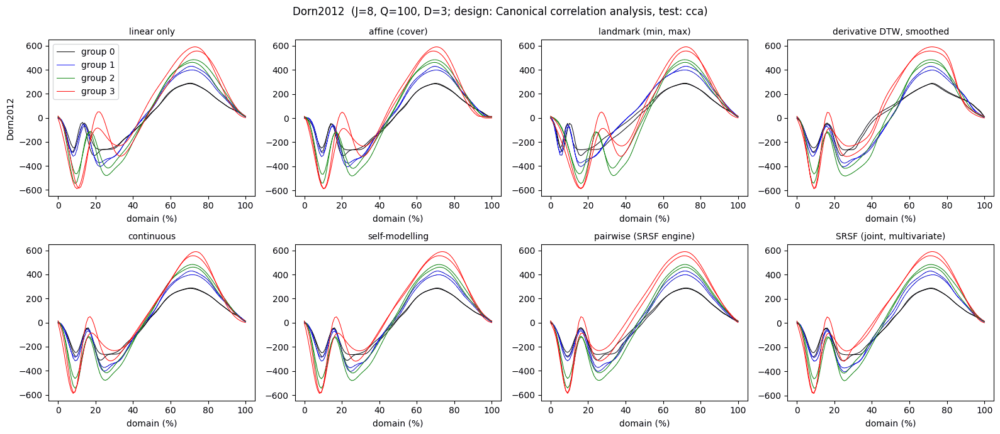

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.857       0.075      0.6
landmark (min, max)               1.070       0.083      0.0
derivative DTW, smoothed          0.939       0.073      0.5
continuous                        0.623       0.056      1.6
self-modelling                    0.761       0.059      2.6
pairwise (SRSF engine)            0.784       0.071      2.6
SRSF (joint, multivariate)        0.801       0.100      5.4


In [3]:
y, g, out = analyse('Dorn2012')

## Dorn2012manova

The same observations as **Dorn2012** with speed treated as a categorical factor (one-way MANOVA).

**Design.** Registration is identical to the regression case: the same warps serve both analyses.
This illustrates the general point that registration should not depend on the *test* to be run
afterwards, only (if at all) on the structure of the data; a registration that took the categorical
design into account (group templates) would give different warps for the same physical data
depending on how the analyst chose to code speed, which is undesirable.

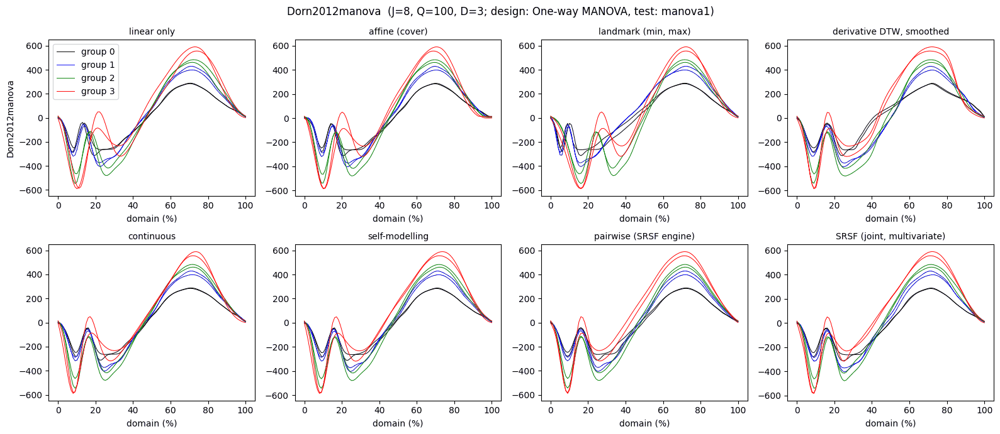

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.857       0.075      0.6
landmark (min, max)               1.070       0.083      0.0
derivative DTW, smoothed          0.939       0.073      0.5
continuous                        0.623       0.056      1.6
self-modelling                    0.761       0.059      2.4
pairwise (SRSF engine)            0.784       0.071      2.6
SRSF (joint, multivariate)        0.801       0.100      4.9


In [4]:
y, g, out = analyse('Dorn2012manova')

## Neptune1999kneekin

Three-dimensional knee kinematics (D = 3), eight subjects in two conditions (paired Hotelling's
T²).

**Auto-tuning.** The curves share one dominant valley, so all methods agree; the differences lie in
how much of the between-subject offset in the flanks is treated as timing. This is a dataset on
which an identifiability diagnostic (the local magnitude of the SRSF relative to the noise level,
flagging regions where the warp is not determined by the data) would be informative, because the
flanks are nearly linear and the warps there are decided by the penalty rather than by features.

**Design.** A paired design suggests registering *within pairs* (the two conditions of a subject
to a subject-specific template, or one condition to the other) so that the warp of each pair
directly measures the within-subject timing effect, and subject-level timing idiosyncrasies never
enter the between-subject variance. That is a strictly stronger use of the design than a pooled
template and would change the downstream paired test on displacement fields into a one-sample test
on within-pair warps.

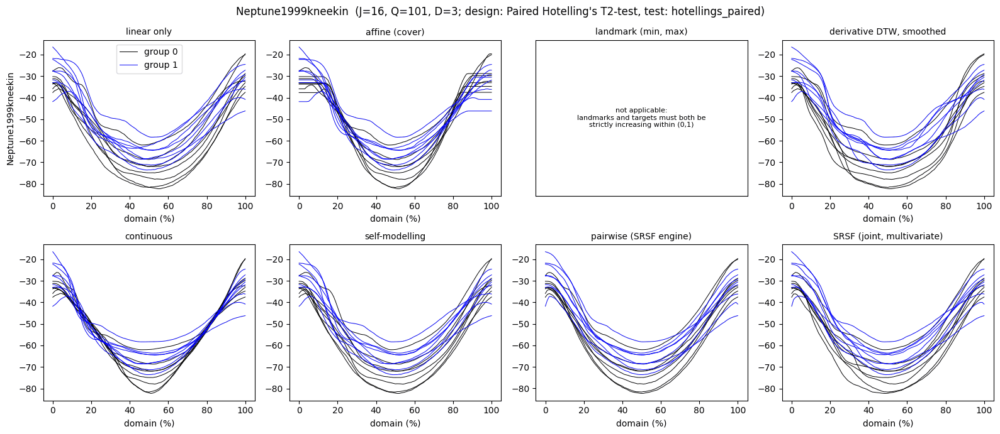

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.567       0.231      0.9
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          1.065       0.095      0.9
continuous                        0.390       0.132      3.2
self-modelling                    0.820       0.102      4.7
pairwise (SRSF engine)            0.772       0.080     11.2
SRSF (joint, multivariate)        0.862       0.086     10.6


In [5]:
y, g, out = analyse('Neptune1999kneekin')

## Pataky2014cop

Centre-of-pressure trajectories (D = 2: mediolateral and anteroposterior) for two walking
conditions (paired Hotelling's T²).

**Auto-tuning.** These are planar *curves* parametrised by time, not two independent functions.
The joint vector-SRSF registration is the right object mathematically (it is the square-root
velocity function of the curve), but for curves one may want *shape* alignment that also removes
translation, rotation and scaling before registration; whether the coordinate frame is part of
the signal (as here: the foot's position on the plate is meaningful) or a nuisance is a modelling
decision that no data-driven rule can make. The implication for tuning is that multivariate inputs
should carry a flag distinguishing "several signals on a common time base" from "coordinates of one
curve".

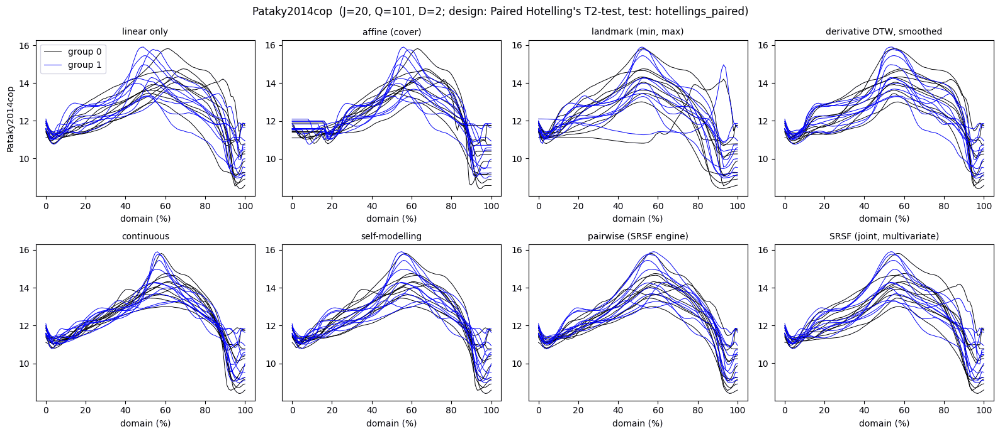

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.674       0.200      1.1
landmark (min, max)               1.469       0.574      0.0
derivative DTW, smoothed          0.838       0.142      1.1
continuous                        0.411       0.196      4.6
self-modelling                    0.578       0.245      8.9
pairwise (SRSF engine)            0.614       0.162     17.5
SRSF (joint, multivariate)        0.812       0.107     11.5


In [6]:
y, g, out = analyse('Pataky2014cop')

## PlantarArchAngle

Plantar arch angle during stance for two conditions (two-sample t-test). The curves are almost
monotonic with a single sharp drop near the end of stance and no interior extrema.

**Auto-tuning.** Automatic extremum landmarks fail (the global minimum and maximum sit on the
domain boundary), and every elastic method has essentially one feature to align, the drop. The
SSE reduction is therefore small and mostly comes from warping the nearly linear middle section,
which is not identified by the data. A useful automatic screen is the number of interior extrema
per curve (here zero for most curves): with fewer than two, landmark registration should default to
slope-based events (e.g. the time of the steepest descent) and the elastic penalty should be
increased, since the warps are otherwise governed by noise.

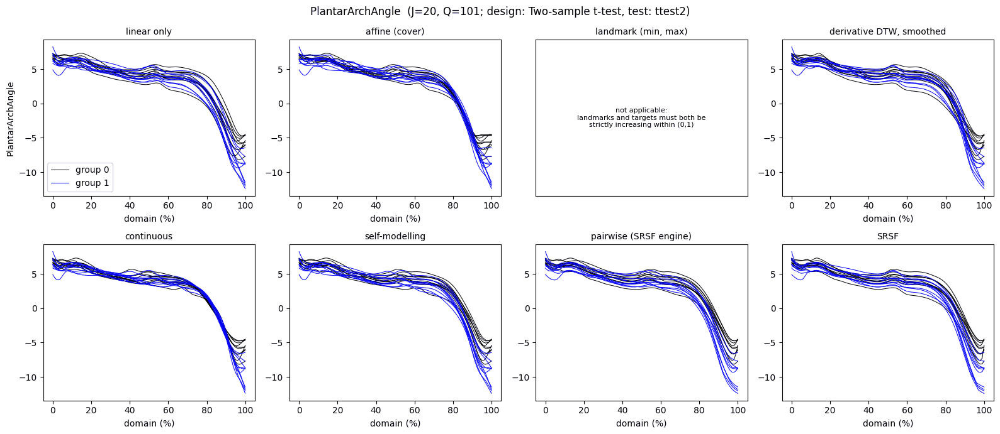

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.549       0.200      1.3
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.829       0.113      1.2
continuous                        0.446       0.157      3.1
self-modelling                    0.786       0.072      5.0
pairwise (SRSF engine)            0.987       0.149     17.9
SRSF                              0.999       0.084      4.9


In [7]:
y, g, out = analyse('PlantarArchAngle')

## Random

Ten realisations of a smooth Gaussian random field (one-sample t-test), i.e. curves with no
common features at all.

**Auto-tuning.** Every method still "registers" these curves and reduces the residual sum of
squares, because a flexible warp can always move bumps of one realisation onto bumps of another.
This is the central hazard of automatic registration: an objective-function improvement is not
evidence of a real timing structure. A registrability test is needed before any tuning — for
example, compare the SRSF cost reduction obtained on the data with the reduction obtained on
surrogate data with the same smoothness but no common structure (phase-randomised or
time-reversed-and-shuffled copies); if the observed reduction is not larger than the surrogate
distribution, registration should be declined rather than tuned. See the additional figure under
**SPM1D_ANOVA2NESTED_2x2** for the size of this effect.

**Auto-tuning: the SSE ratio is not a tuning criterion.** The continuous (Ramsay-Li) method
reaches the smallest SSE ratio on these noise curves, with displacements of half the domain: its
low-dimensional warps *pinch* all curves towards common crossing points (visible as nodes in the
`continuous` panel) rather than align features, and the self-modelling method, which fits an
amplitude model as well, can even increase the residual. Any automatic rule that selects the
penalty or the number of basis functions by minimising the residual will therefore select the
most distorting warps; a tuning criterion must trade the residual against a warp-roughness or
displacement penalty (as `lam` does for SRSF) or be validated on held-out curves, and the
continuous method needs a data-driven `lam` of the same kind as the SRSF `lam='auto'` rule.
Pairwise synchronisation is the most conservative method on featureless data (SSE ratio close to
one on all the random-field datasets), because averaging the pairwise warps cancels the
observation-specific noise matches; that robustness is a reason to keep it as a reference despite
its O(J²) cost.

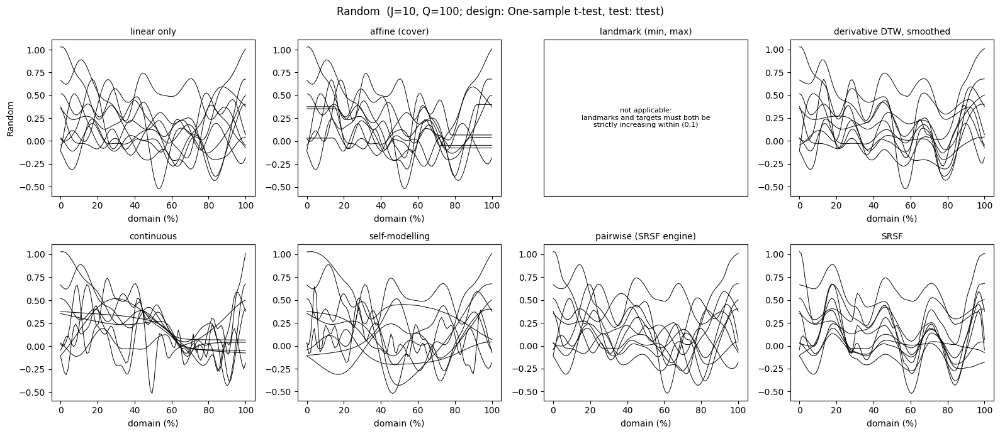

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.831       0.400      0.5
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.849       0.179      0.6
continuous                        0.616       0.567      2.5
self-modelling                    1.167       0.515      4.1
pairwise (SRSF engine)            0.946       0.092      4.3
SRSF                              0.786       0.231      2.5


In [8]:
y, g, out = analyse('Random')

## SPM1D_ANOVA2NESTED_2x2

Simulated smooth random fields with a nested two-factor design (the first of 38 simulated
`SPM1D_ANOVA*` datasets, all of which are random fields without common features; the sections for
the others refer back here).

**Auto-tuning: registration of featureless data.** The additional figure below quantifies the
hazard raised under **Random**: SRSF registration removes 20-40 % of the residual sum of squares
of pure noise fields, most for rough fields (which offer more bumps to match) and, at every
smoothness, at least as much as it removes from the real SpeedGRF curves. A residual-based
criterion therefore cannot even distinguish data with features from data without. The
permutation/surrogate registrability test proposed under **Random** would reject registration for
all 38 simulated datasets; so would a simpler screen, the absence of extrema whose positions are
consistent across observations (e.g. the standard deviation of the global-maximum time exceeding a
sizeable fraction of the domain). Both are cheap and should run before any automatic tuning.

**A finding about the package.** The first run of this notebook used the affine panel to expose
a bug: on featureless data the local refinement of `register_affine` left the `scale_range` /
`max_shift` search box and shrank curves by factors of up to 100 (the residual of a curve squeezed
to a point and padded is trivially small). The refinement is now confined to the search box (and
a test added). Featureless data are a useful stress test for every method's constraints and
should be part of the test suite for any automatic tuning rule.

**Design.** In a nested design (factor B nested in A: e.g. subjects within groups) observations
of different nesting units are not exchangeable. Registering everything to one template mixes
unit-level timing into the residuals of the nested test; registering within units (unit-specific
templates, then aligning the unit templates) respects the nesting but produces warps at two
levels. Which level's warps carry the effect of interest depends on the hypothesis, so the design
can *structure* the registration but cannot choose it.

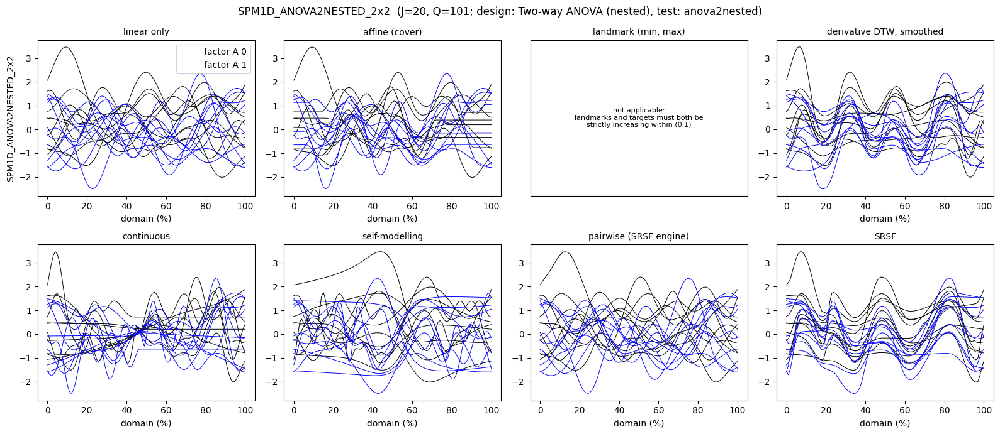

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.874       0.400      1.1
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.809       0.219      1.2
continuous                        0.726       0.552      5.6
self-modelling                    1.364       0.528     10.1
pairwise (SRSF engine)            1.017       0.125     17.9
SRSF                              0.773       0.313      4.7


In [9]:
y, g, out = analyse('SPM1D_ANOVA2NESTED_2x2')

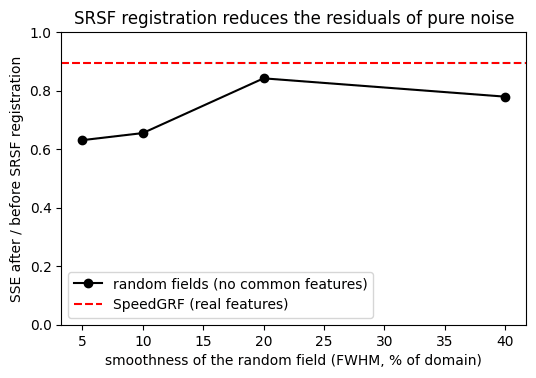

SSE ratios for random fields: [0.631 0.655 0.842 0.779] | SpeedGRF: 0.895


In [10]:
# Registration of featureless data: SRSF SSE reduction on smooth Gaussian random fields of
# increasing smoothness (FWHM), with no common structure, versus the reduction on SpeedGRF.
from scipy.ndimage import gaussian_filter1d
rng = np.random.default_rng(0)
J, Q = 20, 101
fwhms = [5, 10, 20, 40]
ratios = []
for fwhm in fwhms:
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    noise = gaussian_filter1d(rng.standard_normal((J, 3 * Q)), sigma, axis=1)[:, Q:2*Q]
    noise /= noise.std()
    r = reg1d.register_srsf(noise, max_iter=5)
    ratios.append(r.sse()[1] / r.sse()[0])
y_grf = load('SpeedGRF')[0]
r_grf = reg1d.register_srsf(y_grf[:J], max_iter=5)
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(fwhms, ratios, 'ko-', label='random fields (no common features)')
ax.axhline(r_grf.sse()[1] / r_grf.sse()[0], color='r', ls='--', label='SpeedGRF (real features)')
ax.set_xlabel('smoothness of the random field (FWHM, % of domain)')
ax.set_ylabel('SSE after / before SRSF registration')
ax.set_ylim(0, 1); ax.legend(); ax.set_title('SRSF registration reduces the residuals of pure noise')
plt.show()
print('SSE ratios for random fields:', np.round(ratios, 3), '| SpeedGRF:', round(r_grf.sse()[1] / r_grf.sse()[0], 3))

## SPM1D_ANOVA2NESTED_2x3

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2**.

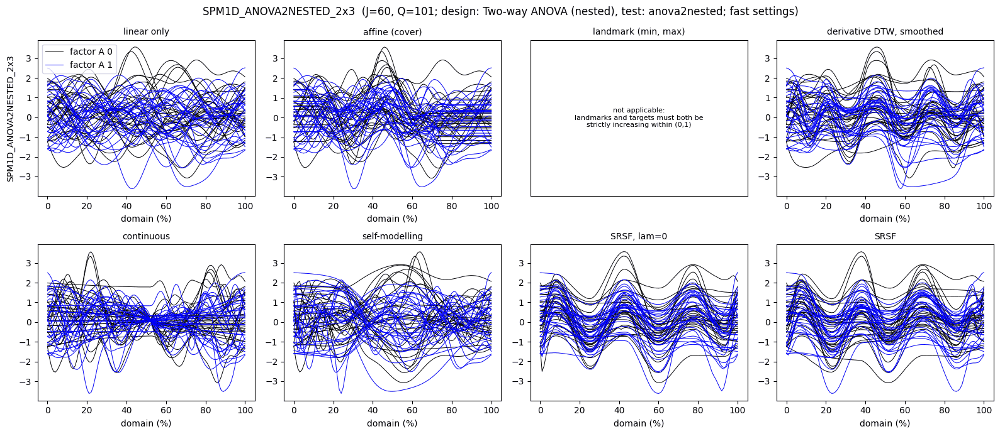

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.822       0.400      1.1
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.885       0.247      2.3
continuous                        0.684       0.540      7.7
self-modelling                    1.070       0.608     11.8
SRSF, lam=0                       0.728       0.313      7.5
SRSF                              0.775       0.343      7.6


In [11]:
y, g, out = analyse('SPM1D_ANOVA2NESTED_2x3')

## SPM1D_ANOVA2NESTED_3x3

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2**.

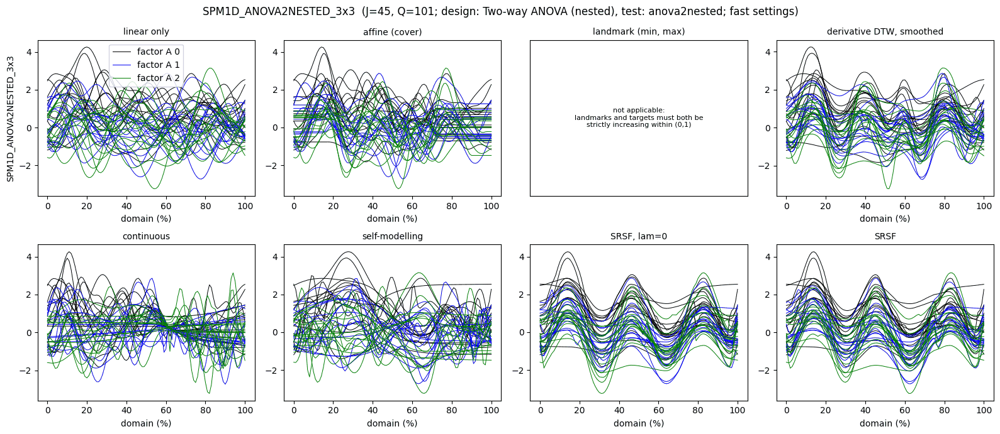

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.783       0.400      0.9
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.781       0.226      1.9
continuous                        0.644       0.627      6.7
self-modelling                    1.069       0.578     11.3
SRSF, lam=0                       0.725       0.274      5.3
SRSF                              0.702       0.257      5.5


In [12]:
y, g, out = analyse('SPM1D_ANOVA2NESTED_3x3')

## SPM1D_ANOVA2NESTED_3x4

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2**.

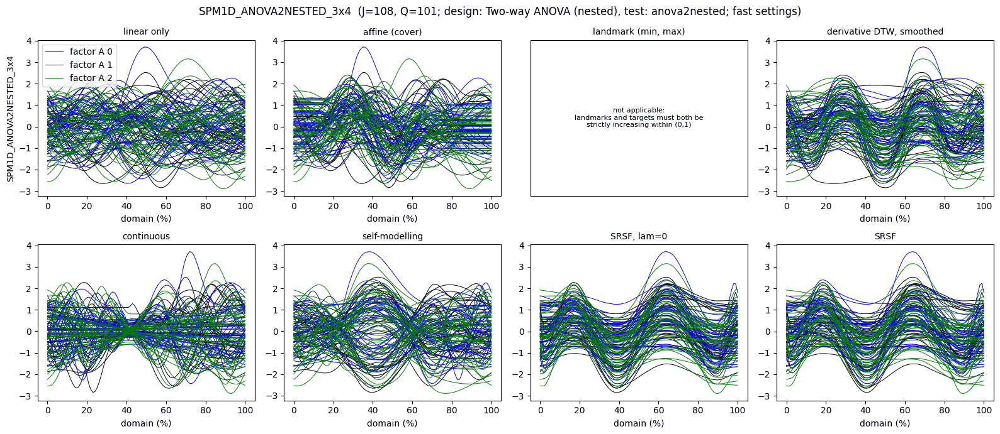

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.826       0.400      2.1
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.903       0.297      4.6
continuous                        0.712       0.594     13.1
self-modelling                    1.024       0.473     20.0
SRSF, lam=0                       0.734       0.433     13.6
SRSF                              0.745       0.396     13.9


In [13]:
y, g, out = analyse('SPM1D_ANOVA2NESTED_3x4')

## SPM1D_ANOVA2NESTED_3x5

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2**.

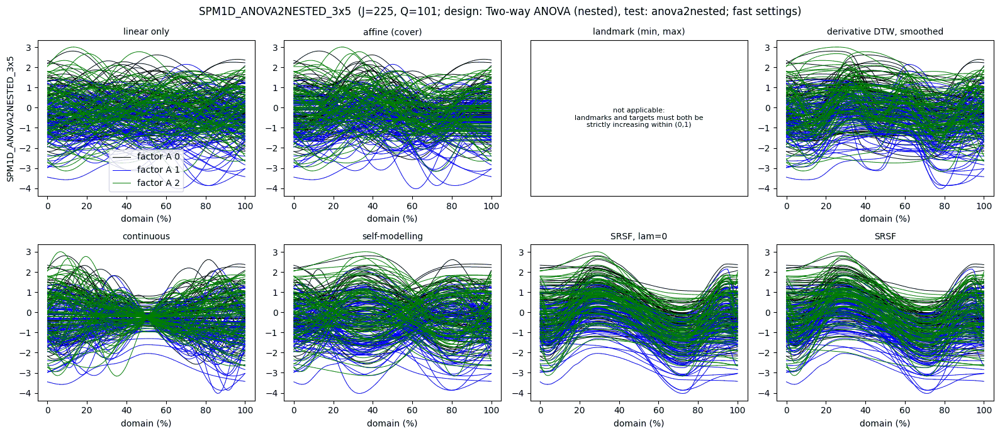

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.881       0.400      4.0
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.994       0.310      9.1
continuous                        0.747       0.514     23.2
self-modelling                    1.080       0.497     22.7
SRSF, lam=0                       0.807       0.523     27.1
SRSF                              0.820       0.513     28.3


In [14]:
y, g, out = analyse('SPM1D_ANOVA2NESTED_3x5')

## SPM1D_ANOVA2NESTED_4x4

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2**.

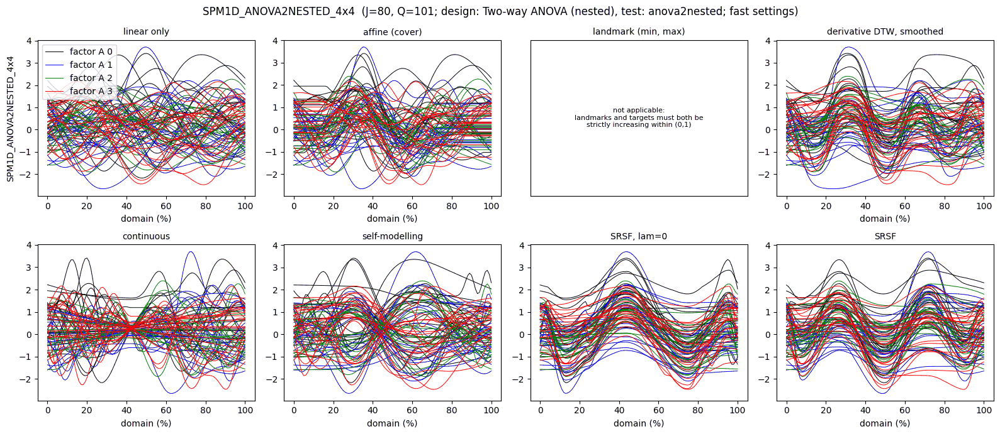

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.808       0.400      1.4
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.898       0.287      2.9
continuous                        0.700       0.586      9.8
self-modelling                    1.033       0.571     12.9
SRSF, lam=0                       0.692       0.460      9.8
SRSF                              0.798       0.346      9.9


In [15]:
y, g, out = analyse('SPM1D_ANOVA2NESTED_4x4')

## SPM1D_ANOVA2NESTED_4x5

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2**.

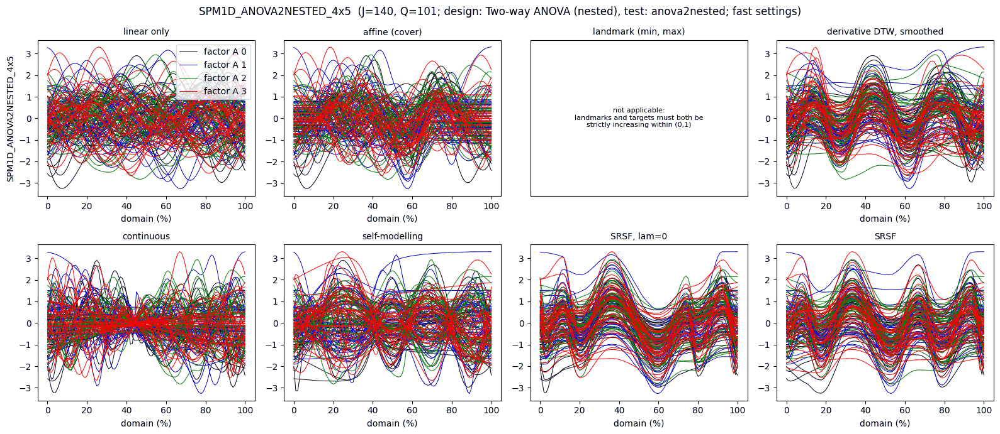

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.806       0.400      2.6
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.835       0.233      5.6
continuous                        0.667       0.593     16.0
self-modelling                    0.972       0.630     30.3
SRSF, lam=0                       0.723       0.381     17.3
SRSF                              0.777       0.325     17.9


In [16]:
y, g, out = analyse('SPM1D_ANOVA2NESTED_4x5')

## SPM1D_ANOVA2ONERM_2x2

Simulated random fields with one repeated-measures factor.

**Design.** A repeated-measures factor identifies observations from the same subject. The
natural design-aware registration is hierarchical: a subject-level warp (the subject's mean
timing) composed with a condition-level warp. Registering to a pooled template instead
attributes the subject-level timing to the residual of every condition, inflating the error term
of the repeated-measures test exactly as unmodelled subject effects do in the amplitude analysis.
This is the strongest case for using design information at the registration stage — but the same
subject warps must then be treated as random effects in the timing analysis, or the test on
displacement fields will be anti-conservative.

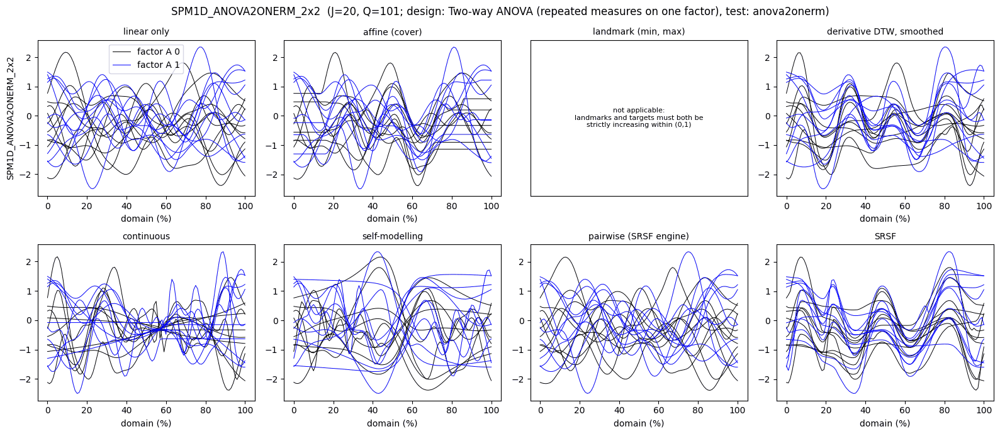

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.822       0.400      1.0
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.794       0.219      1.2
continuous                        0.703       0.570      5.5
self-modelling                    1.341       0.527      9.9
pairwise (SRSF engine)            1.008       0.125     18.4
SRSF                              0.717       0.313      4.9


In [17]:
y, g, out = analyse('SPM1D_ANOVA2ONERM_2x2')

## SPM1D_ANOVA2ONERM_2x3

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2ONERM_2x2**.

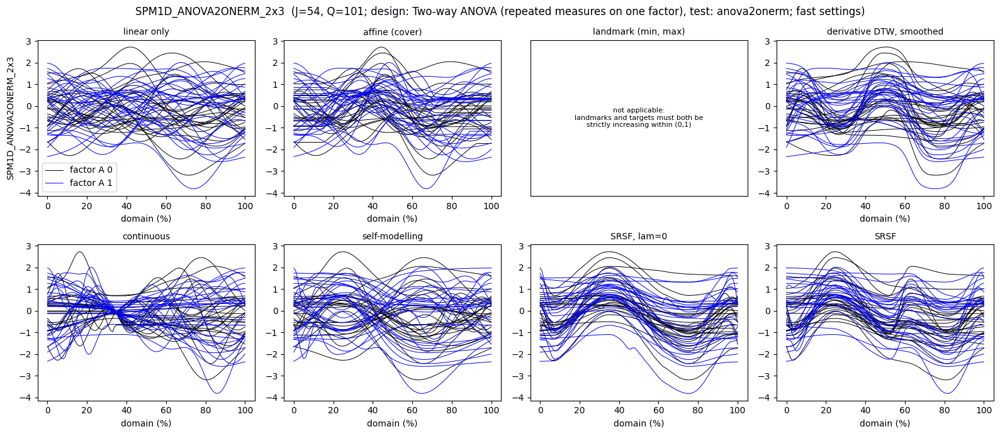

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.843       0.400      1.2
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.951       0.280      2.1
continuous                        0.716       0.647      6.7
self-modelling                    1.079       0.496      7.9
SRSF, lam=0                       0.785       0.462      7.0
SRSF                              0.812       0.485      6.9


In [18]:
y, g, out = analyse('SPM1D_ANOVA2ONERM_2x3')

## SPM1D_ANOVA2ONERM_3x3

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2ONERM_2x2**.

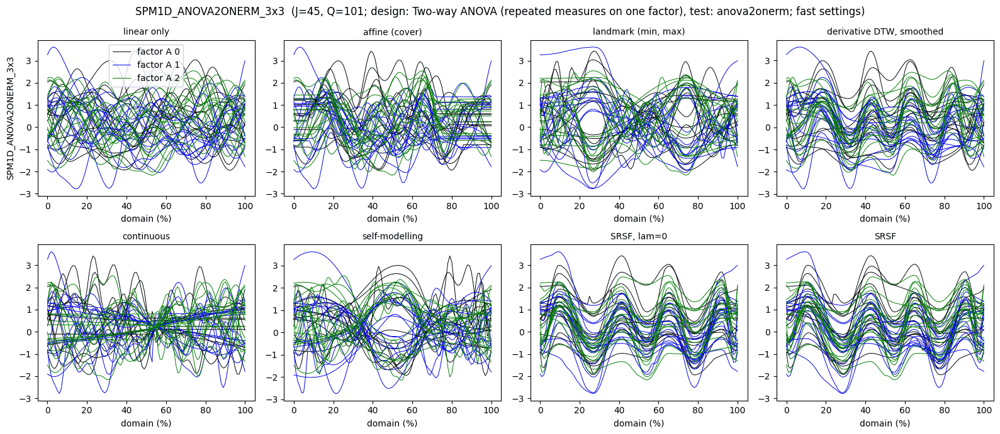

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.810       0.400      0.8
landmark (min, max)               1.194       0.513      0.0
derivative DTW, smoothed          0.858       0.219      1.8
continuous                        0.679       0.540      6.8
self-modelling                    0.961       0.579     11.1
SRSF, lam=0                       0.741       0.312      5.5
SRSF                              0.762       0.294      6.0


In [19]:
y, g, out = analyse('SPM1D_ANOVA2ONERM_3x3')

## SPM1D_ANOVA2ONERM_3x4

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2ONERM_2x2**.

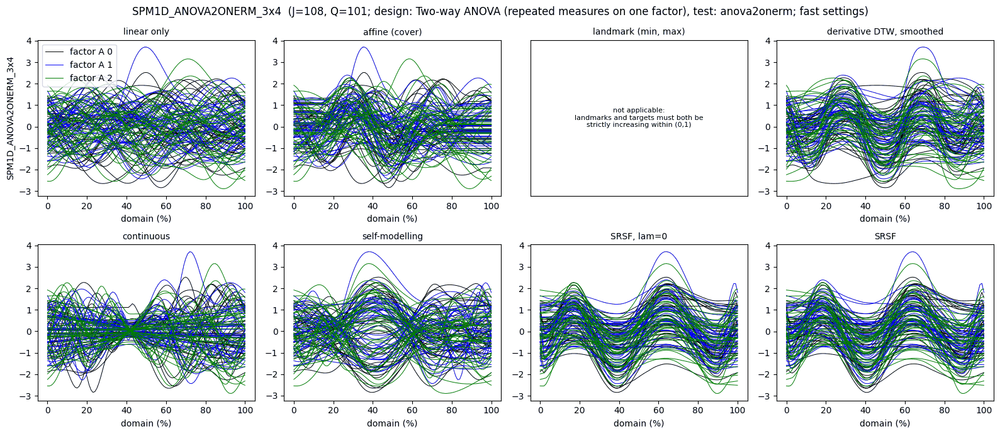

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.826       0.400      2.0
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.903       0.297      4.4
continuous                        0.712       0.594     13.4
self-modelling                    1.024       0.473     19.3
SRSF, lam=0                       0.734       0.433     13.4
SRSF                              0.745       0.396     13.9


In [20]:
y, g, out = analyse('SPM1D_ANOVA2ONERM_3x4')

## SPM1D_ANOVA2ONERM_3x5

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2ONERM_2x2**.

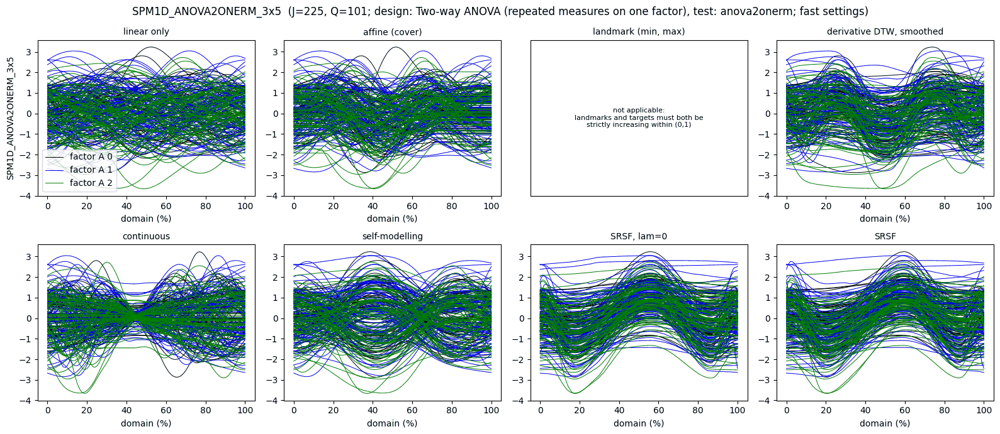

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.865       0.400      4.0
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.971       0.325      8.6
continuous                        0.746       0.558     20.7
self-modelling                    1.038       0.484     25.2
SRSF, lam=0                       0.801       0.536     27.2
SRSF                              0.785       0.485     28.2


In [21]:
y, g, out = analyse('SPM1D_ANOVA2ONERM_3x5')

## SPM1D_ANOVA2ONERM_4x4

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2ONERM_2x2**.

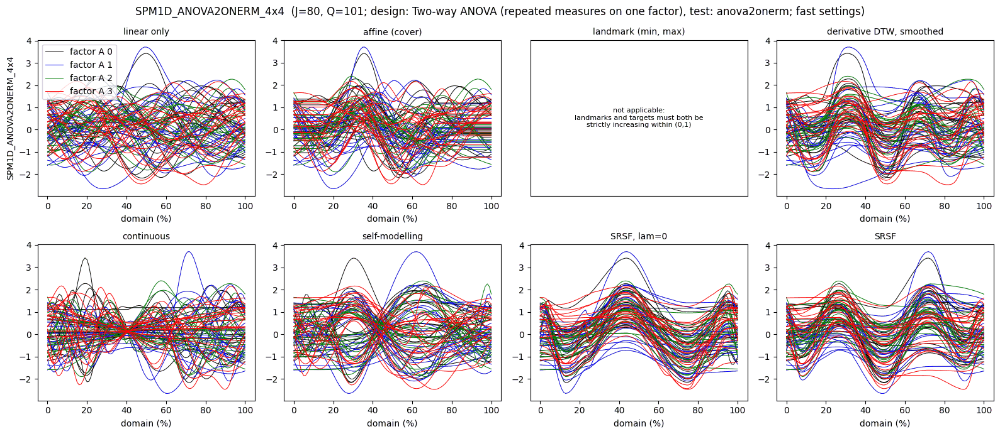

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.797       0.400      1.5
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.889       0.287      3.3
continuous                        0.698       0.604      9.6
self-modelling                    1.045       0.571     12.6
SRSF, lam=0                       0.683       0.460      9.6
SRSF                              0.788       0.346     10.2


In [22]:
y, g, out = analyse('SPM1D_ANOVA2ONERM_4x4')

## SPM1D_ANOVA2ONERM_4x5

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2ONERM_2x2**.

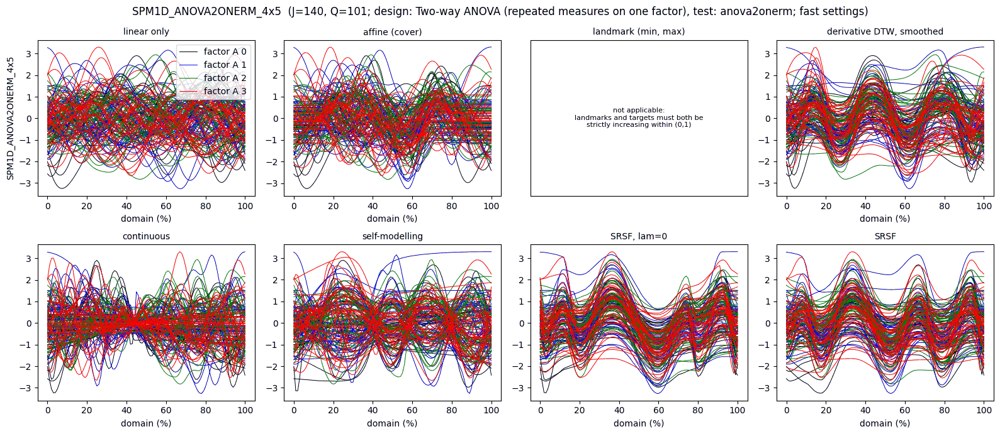

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.806       0.400      2.4
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.835       0.233      5.4
continuous                        0.667       0.593     16.2
self-modelling                    0.972       0.630     29.2
SRSF, lam=0                       0.723       0.381     17.1
SRSF                              0.777       0.325     17.7


In [23]:
y, g, out = analyse('SPM1D_ANOVA2ONERM_4x5')

## SPM1D_ANOVA2RM_2x2

Simulated random fields with two repeated-measures factors.

**Design.** With both factors within subjects the hierarchical decomposition of **SPM1D_ANOVA2ONERM_2x2**
has three levels (subject, factor A, factor B) and an interaction term in the warp group; the
composition of warps is not commutative, so the *order* in which effects are removed becomes a
modelling choice with no counterpart in amplitude ANOVA. This is the main reason for not
implementing design-dependent registration before the corresponding timing model is specified.

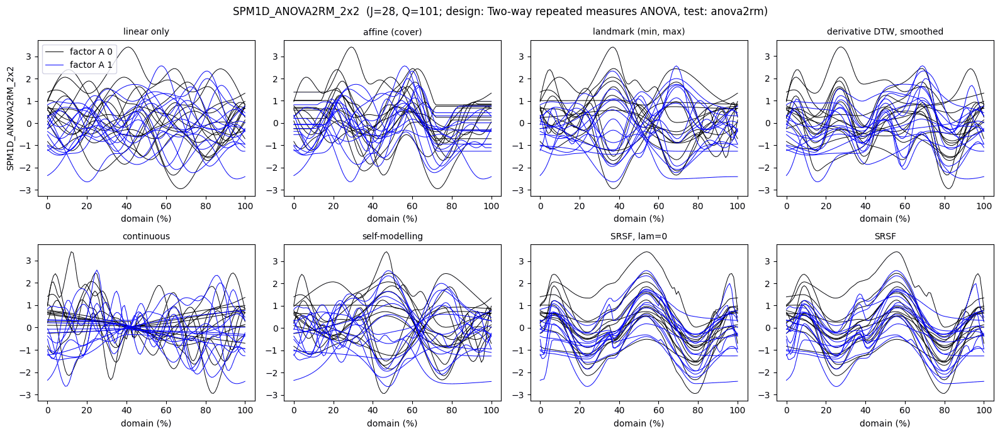

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.738       0.400      1.2
landmark (min, max)               1.046       0.452      0.0
derivative DTW, smoothed          0.800       0.227      1.6
continuous                        0.591       0.580      7.0
self-modelling                    1.013       0.526      9.5
SRSF, lam=0                       0.629       0.370      6.8
SRSF                              0.642       0.341      6.6


In [24]:
y, g, out = analyse('SPM1D_ANOVA2RM_2x2')

## SPM1D_ANOVA2RM_2x3

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2RM_2x2**.

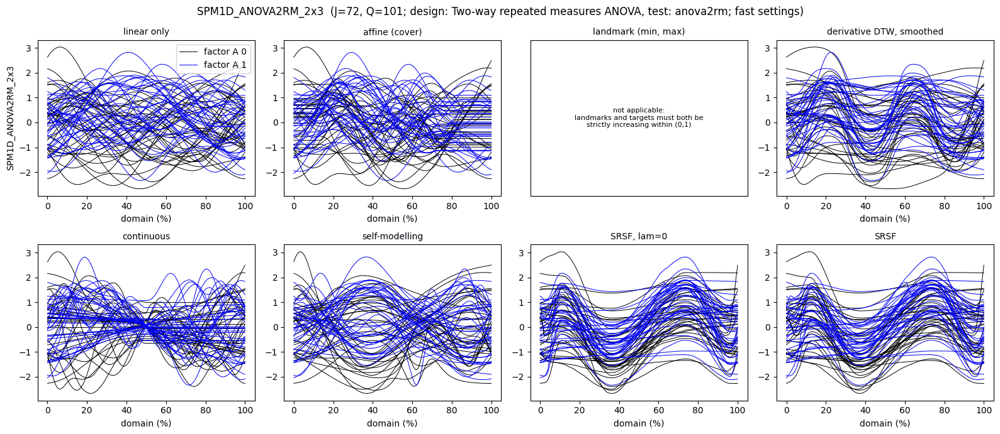

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.862       0.400      1.2
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.990       0.298      2.8
continuous                        0.688       0.505      7.9
self-modelling                    0.974       0.435     11.9
SRSF, lam=0                       0.740       0.455      8.9
SRSF                              0.756       0.422      9.7


In [25]:
y, g, out = analyse('SPM1D_ANOVA2RM_2x3')

## SPM1D_ANOVA2RM_3x3

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2RM_2x2**.

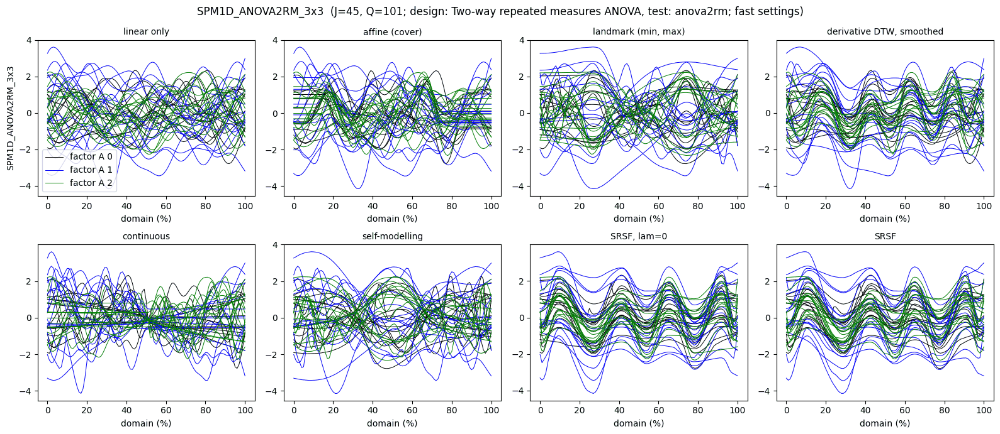

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.847       0.400      1.0
landmark (min, max)               1.225       0.513      0.0
derivative DTW, smoothed          0.920       0.219      1.9
continuous                        0.680       0.521      6.7
self-modelling                    1.025       0.569     11.7
SRSF, lam=0                       0.848       0.312      5.7
SRSF                              0.837       0.294      6.0


In [26]:
y, g, out = analyse('SPM1D_ANOVA2RM_3x3')

## SPM1D_ANOVA2RM_3x4

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2RM_2x2**.

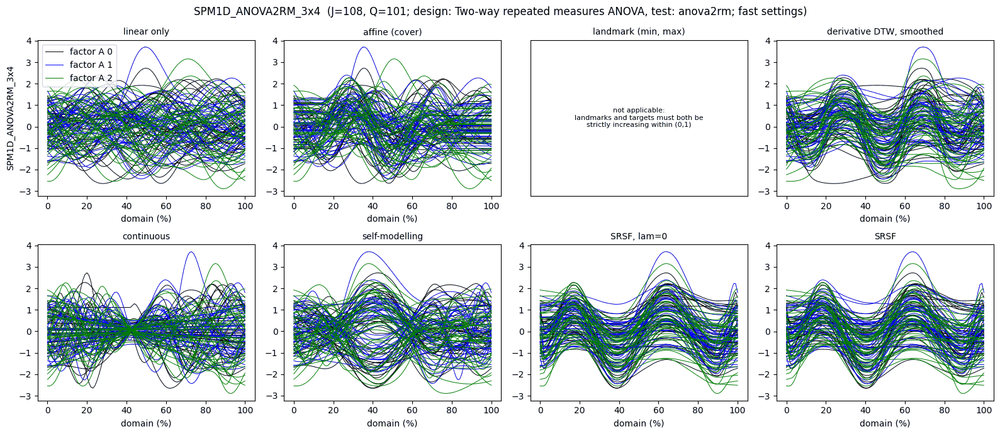

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.825       0.400      2.0
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.902       0.297      4.3
continuous                        0.714       0.586     13.2
self-modelling                    1.027       0.473     21.2
SRSF, lam=0                       0.731       0.433     13.9
SRSF                              0.742       0.396     14.1


In [27]:
y, g, out = analyse('SPM1D_ANOVA2RM_3x4')

## SPM1D_ANOVA2RM_3x5

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2RM_2x2**.

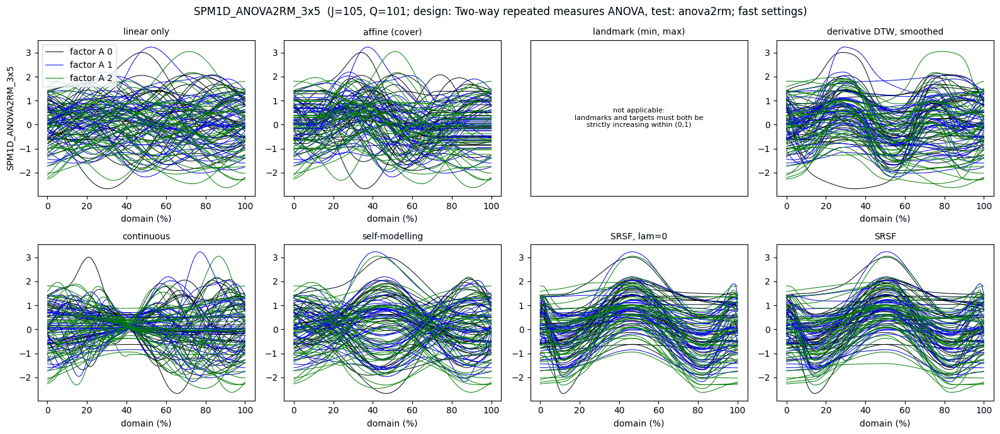

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.846       0.400      1.8
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.966       0.334      4.1
continuous                        0.729       0.591     11.6
self-modelling                    0.988       0.432     14.3
SRSF, lam=0                       0.774       0.512     12.9
SRSF                              0.784       0.473     13.6


In [28]:
y, g, out = analyse('SPM1D_ANOVA2RM_3x5')

## SPM1D_ANOVA2RM_4x4

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2RM_2x2**.

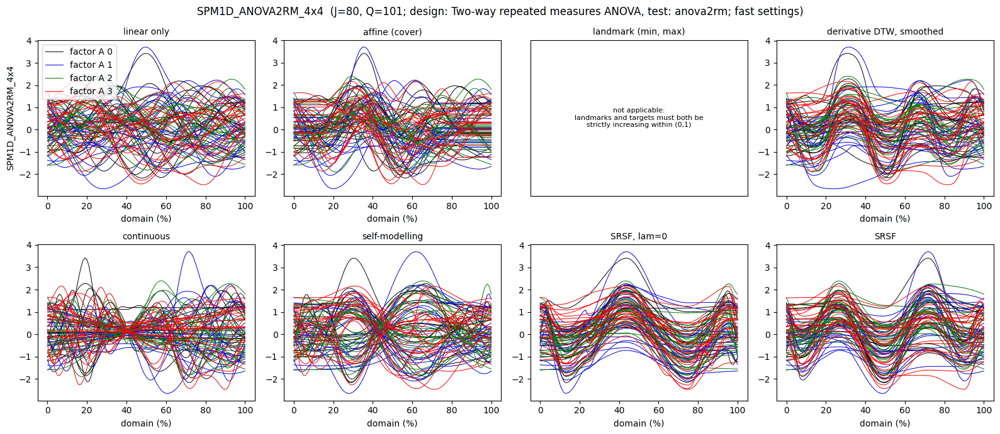

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.797       0.400      1.4
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.889       0.287      3.2
continuous                        0.698       0.604      9.1
self-modelling                    1.045       0.571     12.6
SRSF, lam=0                       0.683       0.460     10.2
SRSF                              0.788       0.346     10.2


In [29]:
y, g, out = analyse('SPM1D_ANOVA2RM_4x4')

## SPM1D_ANOVA2RM_4x5

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2RM_2x2**.

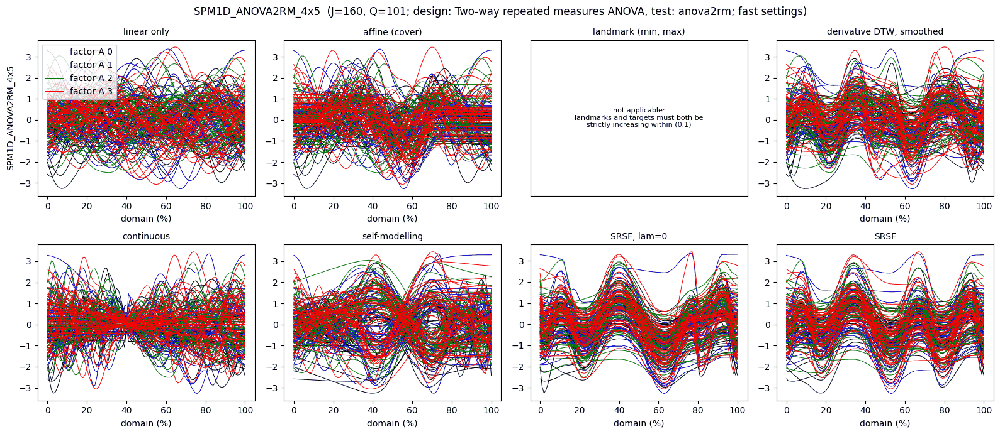

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.811       0.400      3.0
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.828       0.268      6.5
continuous                        0.691       0.622     19.1
self-modelling                    1.157       0.629     30.9
SRSF, lam=0                       0.721       0.396     19.4
SRSF                              0.769       0.326     20.0


In [30]:
y, g, out = analyse('SPM1D_ANOVA2RM_4x5')

## SPM1D_ANOVA2_2x2

Simulated random fields with two crossed between-subject factors.

**Design.** Crossed factors raise the question of cell-wise versus marginal templates: a
template per cell removes the interaction in timing from the warps, marginal templates remove
the main effects only. Any such choice pre-empts the interaction test on displacement fields, so
if design information were used here it would have to be recorded in the result (which effects the
registration has already absorbed) for the downstream analysis to remain interpretable.

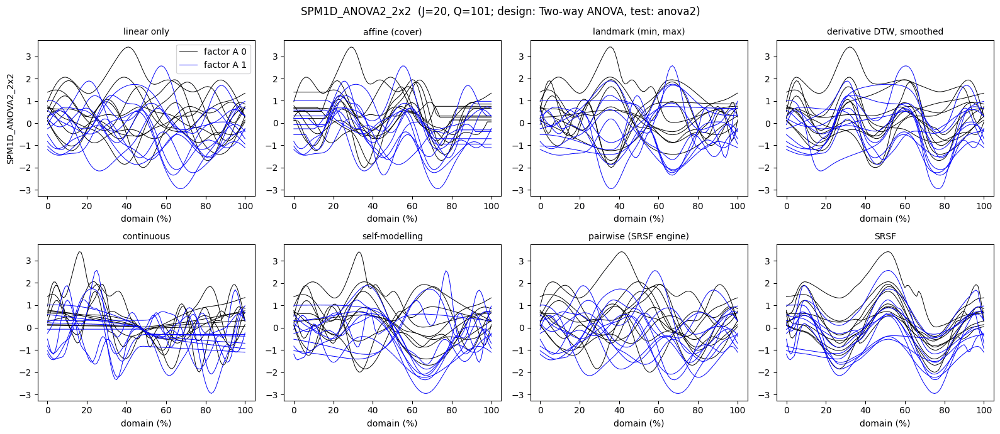

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.709       0.400      0.9
landmark (min, max)               0.982       0.454      0.0
derivative DTW, smoothed          0.803       0.195      1.2
continuous                        0.521       0.516      4.6
self-modelling                    0.898       0.410      8.1
pairwise (SRSF engine)            0.948       0.137     18.1
SRSF                              0.599       0.289      4.7


In [31]:
y, g, out = analyse('SPM1D_ANOVA2_2x2')

## SPM1D_ANOVA2_2x3

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2_2x2**.

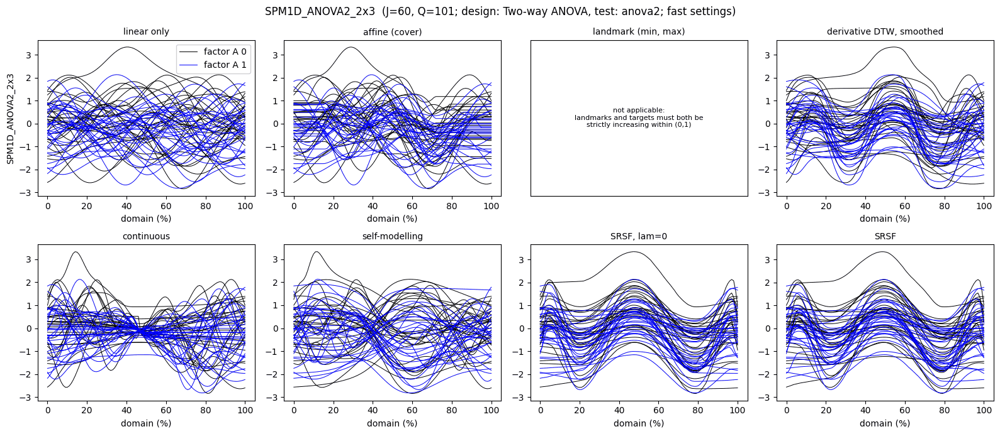

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.829       0.400      1.1
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.854       0.296      2.4
continuous                        0.678       0.535      7.8
self-modelling                    1.069       0.486      9.3
SRSF, lam=0                       0.779       0.391      7.8
SRSF                              0.779       0.393      7.7


In [32]:
y, g, out = analyse('SPM1D_ANOVA2_2x3')

## SPM1D_ANOVA2_3x3

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2_2x2**.

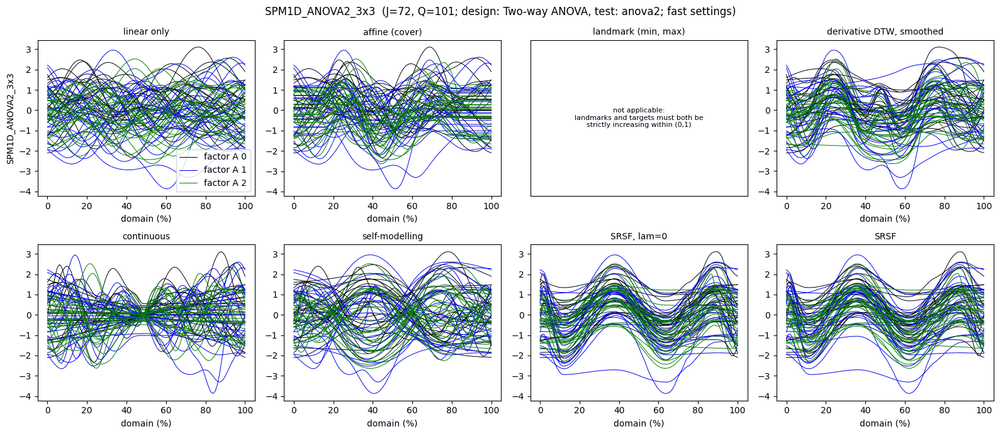

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.823       0.400      1.3
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.856       0.293      2.9
continuous                        0.677       0.537      8.8
self-modelling                    1.146       0.473     13.6
SRSF, lam=0                       0.745       0.376      9.0
SRSF                              0.757       0.351      9.2


In [33]:
y, g, out = analyse('SPM1D_ANOVA2_3x3')

## SPM1D_ANOVA2_3x4

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2_2x2**.

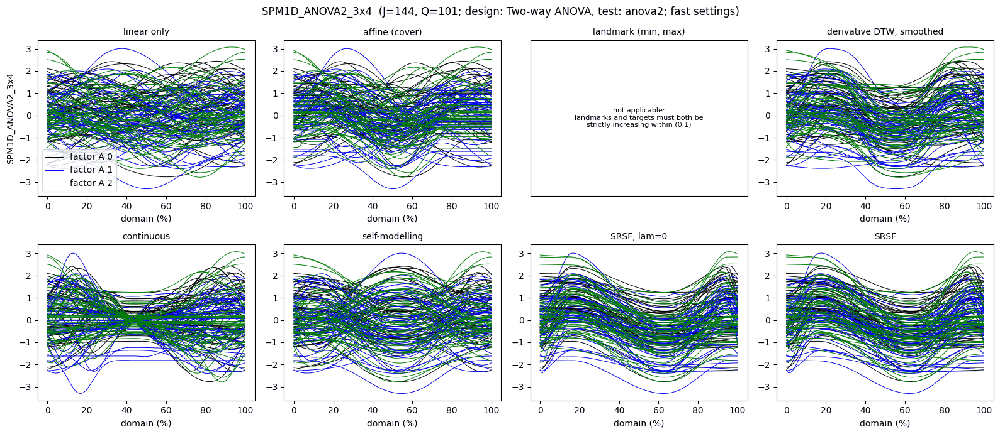

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.860       0.400      2.6
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.928       0.310      6.0
continuous                        0.710       0.584     17.4
self-modelling                    1.002       0.424     15.4
SRSF, lam=0                       0.806       0.508     18.1
SRSF                              0.810       0.494     19.2


In [34]:
y, g, out = analyse('SPM1D_ANOVA2_3x4')

## SPM1D_ANOVA2_3x5

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2_2x2**.

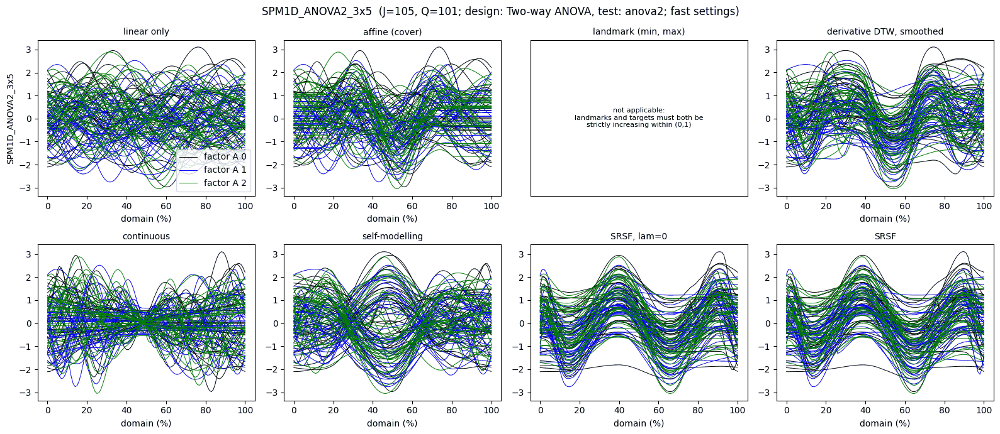

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.807       0.400      2.0
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.830       0.258      4.2
continuous                        0.681       0.533     13.4
self-modelling                    1.041       0.516     19.8
SRSF, lam=0                       0.731       0.402     13.6
SRSF                              0.719       0.370     14.3


In [35]:
y, g, out = analyse('SPM1D_ANOVA2_3x5')

## SPM1D_ANOVA2_4x4

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2_2x2**.

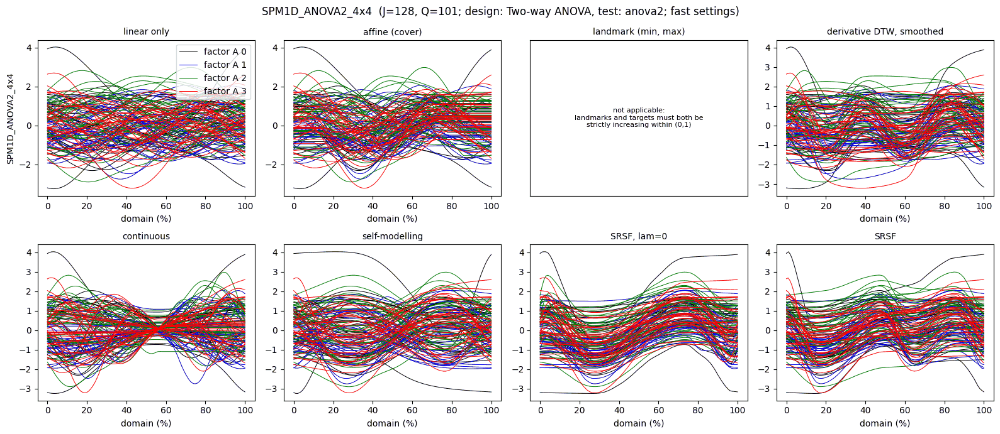

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.855       0.400      2.1
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          1.004       0.327      4.9
continuous                        0.717       0.567     15.6
self-modelling                    1.052       0.496     15.1
SRSF, lam=0                       0.759       0.550     16.4
SRSF                              0.844       0.474     16.8


In [36]:
y, g, out = analyse('SPM1D_ANOVA2_4x4')

## SPM1D_ANOVA2_4x5

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2_2x2**.

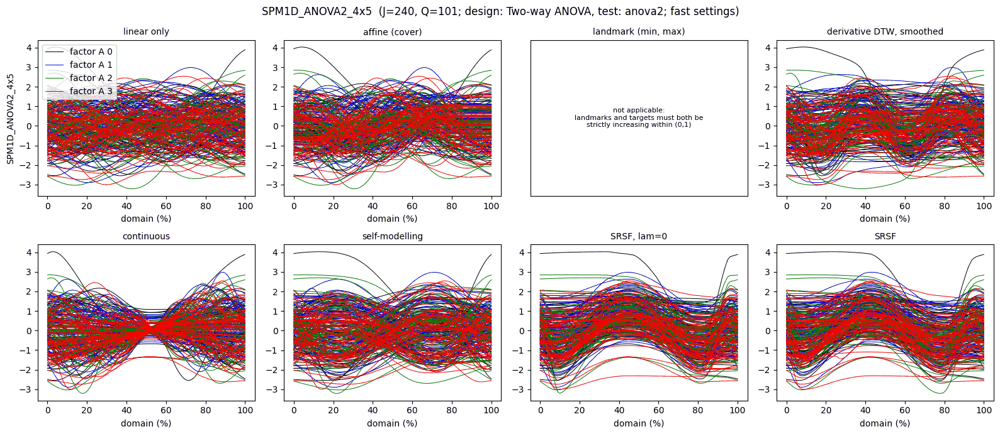

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.877       0.400      4.3
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          1.014       0.321      9.8
continuous                        0.723       0.546     27.5
self-modelling                    1.063       0.626     27.2
SRSF, lam=0                       0.837       0.505     28.8
SRSF                              0.843       0.477     31.0


In [37]:
y, g, out = analyse('SPM1D_ANOVA2_4x5')

## SPM1D_ANOVA3NESTED_2x2x2

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2**.

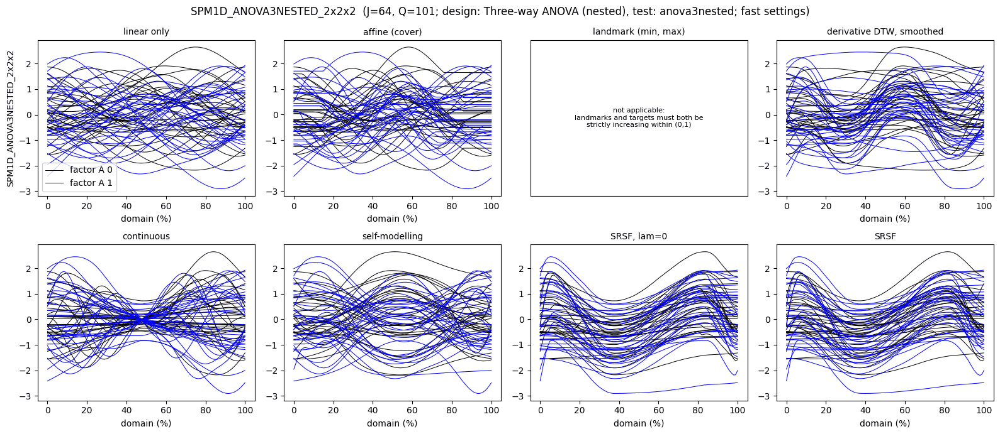

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.884       0.400      1.1
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.974       0.320      2.7
continuous                        0.747       0.534      7.2
self-modelling                    1.014       0.496      6.7
SRSF, lam=0                       0.810       0.518      7.8
SRSF                              0.820       0.495      8.2


In [38]:
y, g, out = analyse('SPM1D_ANOVA3NESTED_2x2x2')

## SPM1D_ANOVA3NESTED_2x4x2

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2**.

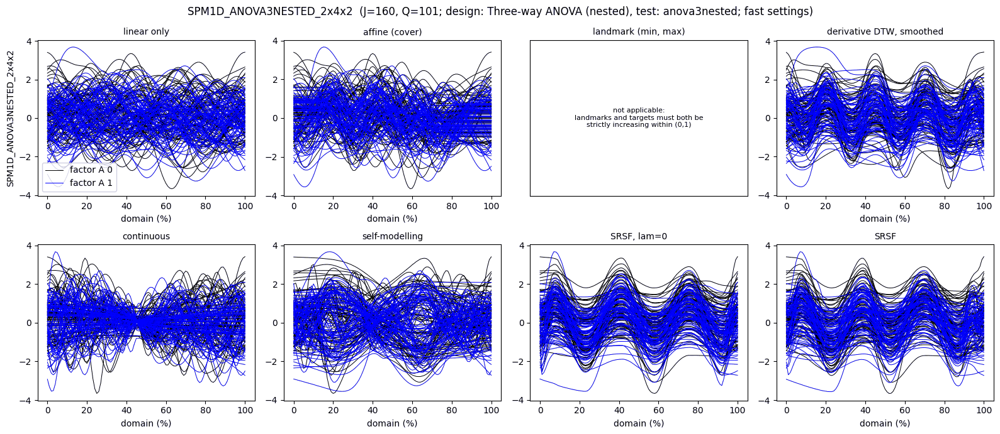

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.836       0.400      2.8
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.870       0.265      6.2
continuous                        0.675       0.560     21.1
self-modelling                    1.163       0.615     29.8
SRSF, lam=0                       0.764       0.324     19.2
SRSF                              0.790       0.317     19.8


In [39]:
y, g, out = analyse('SPM1D_ANOVA3NESTED_2x4x2')

## SPM1D_ANOVA3ONERM_2x2x2

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2ONERM_2x2**.

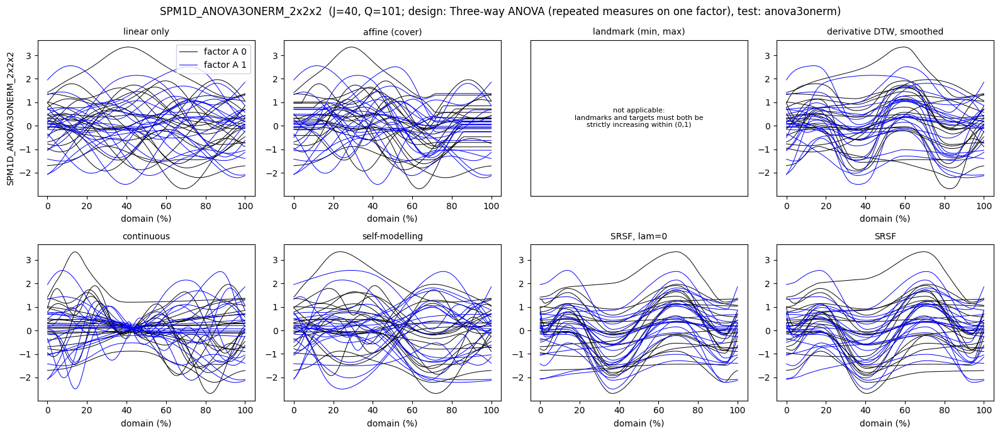

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.828       0.400      1.6
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.918       0.249      2.4
continuous                        0.661       0.580      9.4
self-modelling                    1.025       0.432      9.4
SRSF, lam=0                       0.873       0.385      9.9
SRSF                              0.881       0.382     10.4


In [40]:
y, g, out = analyse('SPM1D_ANOVA3ONERM_2x2x2')

## SPM1D_ANOVA3ONERM_2x3x4

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2ONERM_2x2**.

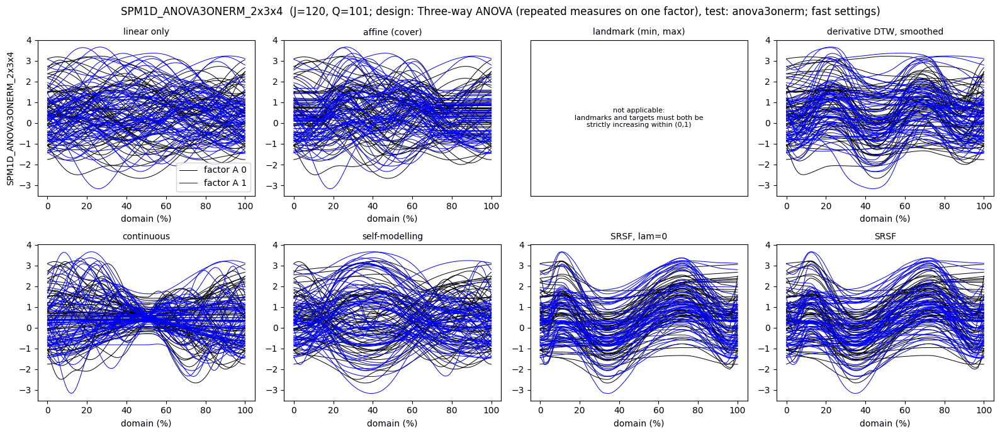

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.873       0.400      2.3
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.944       0.325      5.0
continuous                        0.693       0.525     14.2
self-modelling                    1.050       0.491     17.9
SRSF, lam=0                       0.781       0.502     15.2
SRSF                              0.792       0.464     15.6


In [41]:
y, g, out = analyse('SPM1D_ANOVA3ONERM_2x3x4')

## SPM1D_ANOVA3RM_2x2x2

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2RM_2x2**.

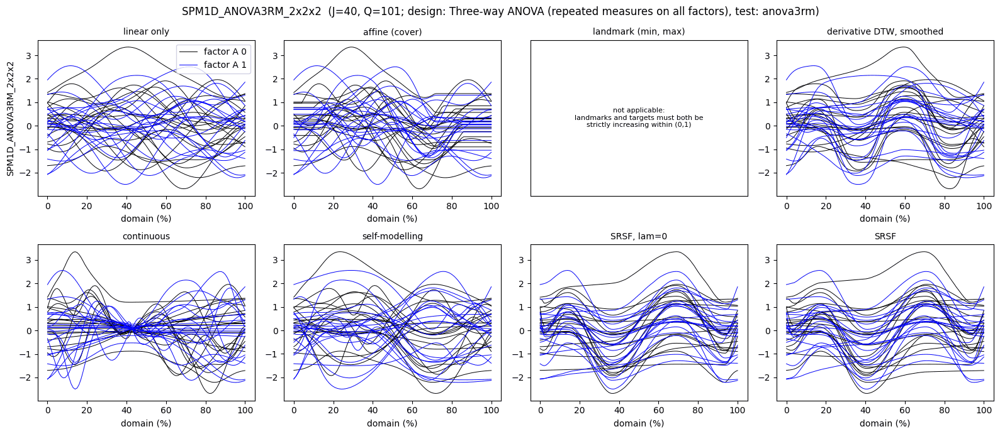

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.828       0.400      1.7
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.918       0.249      2.3
continuous                        0.661       0.580      9.3
self-modelling                    1.025       0.432      9.4
SRSF, lam=0                       0.873       0.385      9.9
SRSF                              0.881       0.382      9.7


In [42]:
y, g, out = analyse('SPM1D_ANOVA3RM_2x2x2')

## SPM1D_ANOVA3RM_2x3x4

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2RM_2x2**.

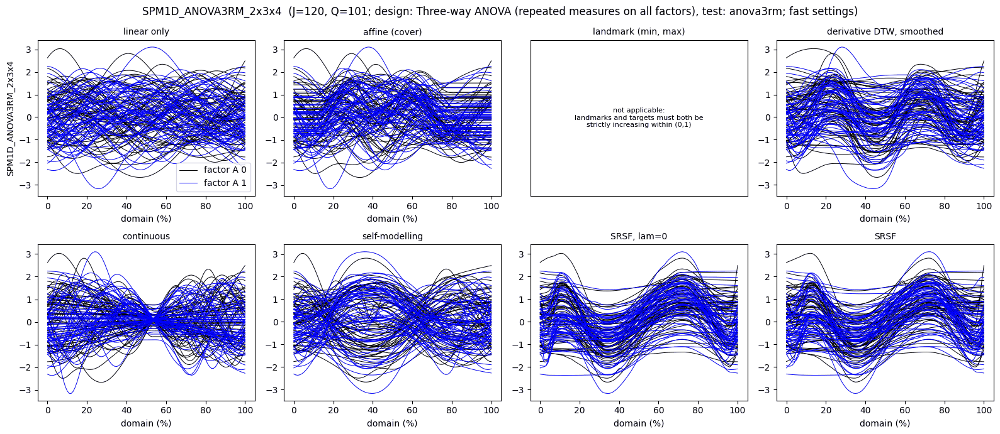

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.859       0.400      2.2
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.928       0.325      4.8
continuous                        0.722       0.542     12.9
self-modelling                    1.040       0.470     17.2
SRSF, lam=0                       0.742       0.502     15.5
SRSF                              0.758       0.464     16.0


In [43]:
y, g, out = analyse('SPM1D_ANOVA3RM_2x3x4')

## SPM1D_ANOVA3TWORM_2x2x2

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2RM_2x2**.

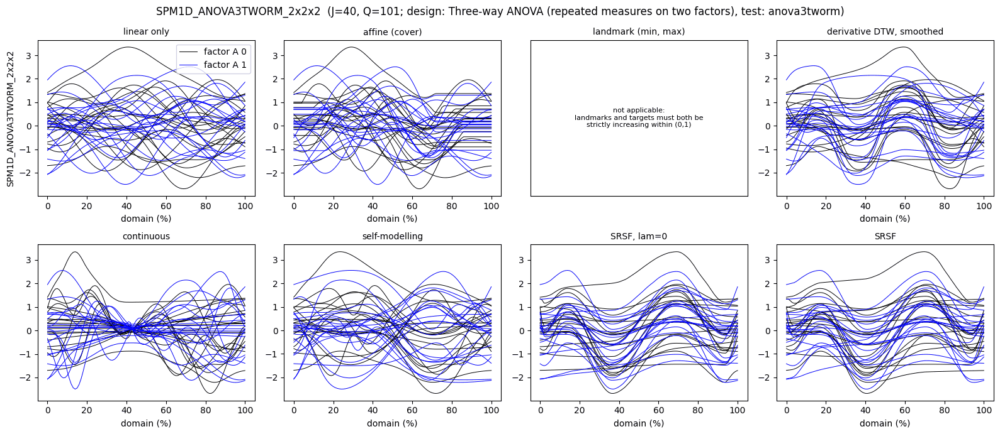

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.828       0.400      1.7
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.918       0.249      2.3
continuous                        0.661       0.580      9.2
self-modelling                    1.025       0.432      9.8
SRSF, lam=0                       0.873       0.385      9.8
SRSF                              0.881       0.382     10.2


In [44]:
y, g, out = analyse('SPM1D_ANOVA3TWORM_2x2x2')

## SPM1D_ANOVA3TWORM_2x3x4

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2RM_2x2**.

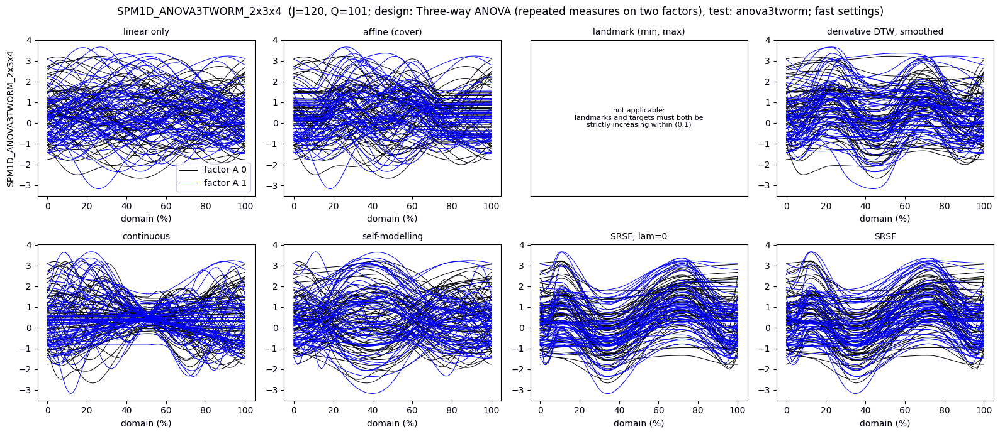

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.873       0.400      2.3
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.943       0.325      5.0
continuous                        0.696       0.524     13.6
self-modelling                    1.032       0.537     16.3
SRSF, lam=0                       0.781       0.502     14.8
SRSF                              0.792       0.464     15.4


In [45]:
y, g, out = analyse('SPM1D_ANOVA3TWORM_2x3x4')

## SPM1D_ANOVA3_2x2x2

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2_2x2**.

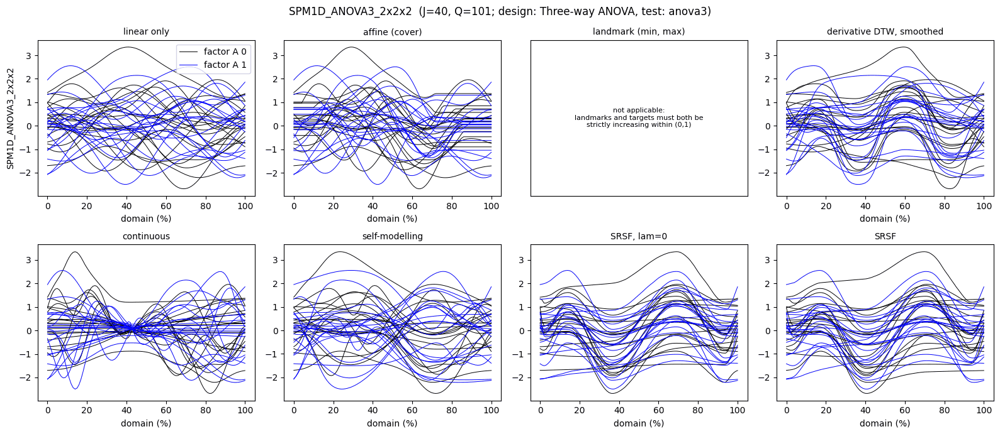

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.828       0.400      1.7
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          0.918       0.249      2.5
continuous                        0.661       0.580      9.1
self-modelling                    1.025       0.432      9.6
SRSF, lam=0                       0.873       0.385      9.8
SRSF                              0.881       0.382      9.8


In [46]:
y, g, out = analyse('SPM1D_ANOVA3_2x2x2')

## SPM1D_ANOVA3_2x3x4

No implications beyond those of **SPM1D_ANOVA2NESTED_2x2** and **SPM1D_ANOVA2_2x2**.

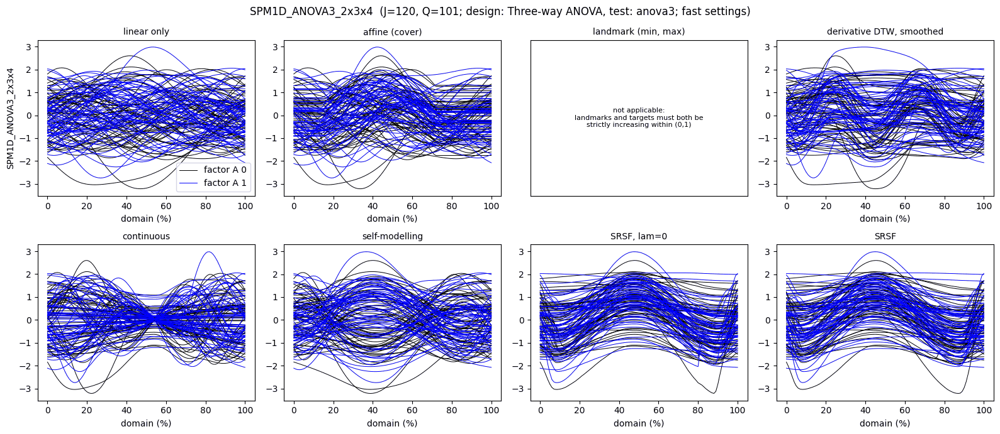

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.845       0.400      2.2
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          1.015       0.323      4.7
continuous                        0.730       0.547     13.4
self-modelling                    0.981       0.470     12.4
SRSF, lam=0                       0.755       0.464     15.5
SRSF                              0.757       0.449     16.3


In [47]:
y, g, out = analyse('SPM1D_ANOVA3_2x3x4')

## SimulatedPataky2015a

Ten simulated curves with a single smooth signal plus smooth noise (one-sample t-test).

**Auto-tuning.** With J = 10 the template is an average of very few curves and the Karcher
iteration can be pulled towards one observation. A leave-one-out stability check (re-register
without each observation and measure how much the warps of the others change) is an inexpensive
automatic diagnostic of template dominance at small sample sizes, and its output (per-observation
influence) is exactly what an interactive tool should show.

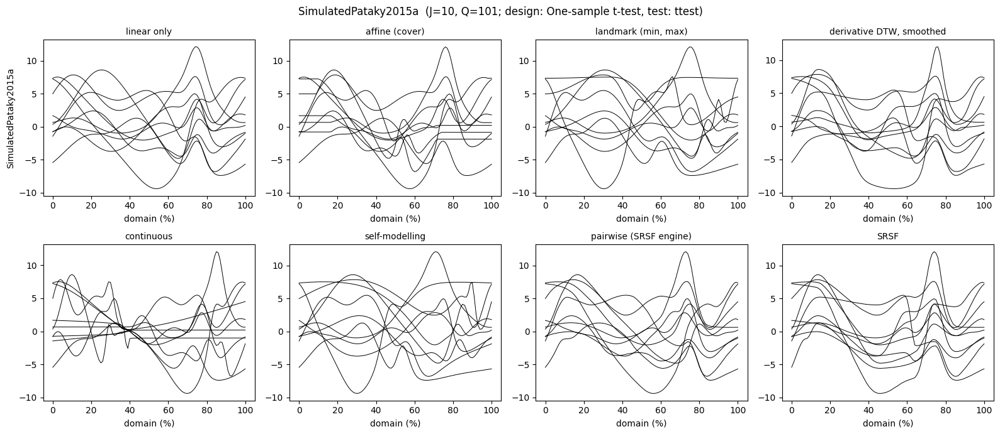

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.812       0.400      0.6
landmark (min, max)               1.270       0.362      0.0
derivative DTW, smoothed          0.911       0.174      0.6
continuous                        0.714       0.598      2.8
self-modelling                    1.300       0.359      5.2
pairwise (SRSF engine)            0.888       0.173      4.2
SRSF                              0.855       0.295      2.7


In [48]:
y, g, out = analyse('SimulatedPataky2015a')

## SimulatedPataky2015b

As **SimulatedPataky2015a** with a different noise realisation; no additional implications.

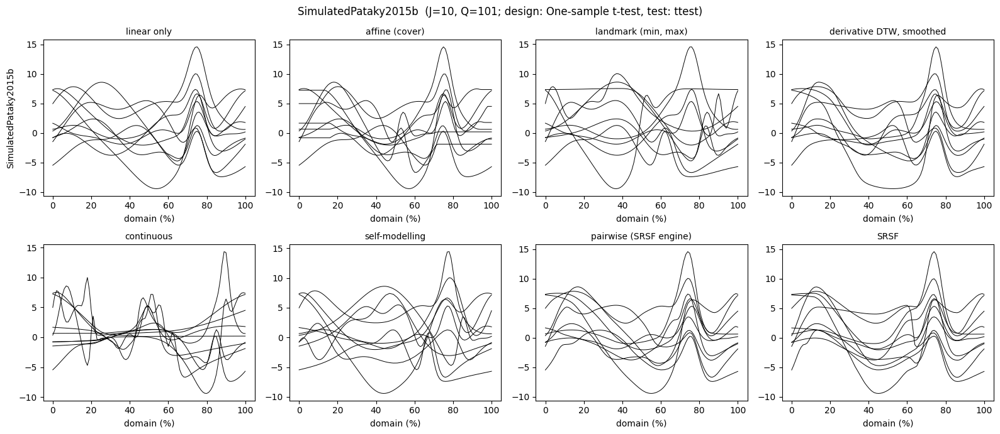

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.842       0.400      0.6
landmark (min, max)               1.281       0.401      0.0
derivative DTW, smoothed          0.931       0.171      0.6
continuous                        0.561       0.680      2.5
self-modelling                    1.160       0.321      7.0
pairwise (SRSF engine)            0.833       0.169      4.6
SRSF                              0.833       0.300      2.6


In [49]:
y, g, out = analyse('SimulatedPataky2015b')

## SimulatedPataky2015c

Ten simulated curves whose single peak varies with a continuous covariate (linear regression).

**Auto-tuning.** Landmark registration on the automatic global extrema increases the residual
almost six-fold here: the curves are flat apart from the signal, so the global minimum and maximum
of each curve are noise extrema at unrelated positions, and forcing them to coincide destroys the
alignment. An automatic landmark rule must therefore test the consistency of the detected event
times across observations (their dispersion relative to the domain) and fall back to no landmarks
when it fails; prominence thresholds alone do not protect against this.

**Design.** The effect of interest is a regression of the curves on the covariate; if the
covariate also shifts the peak in time, registration moves that effect from the amplitude domain
into the warps. Whether that is desirable cannot be decided from the data: it is the difference
between asking "does the amplitude at a fixed time depend on x?" and "does the timing depend on
x?". Design-aware registration (a covariate-dependent template) would make the amplitude
regression blind to the timing effect by construction. The implication is that for regression
designs the software should report *both* analyses (amplitude after registration, displacement
fields against the covariate) rather than choose.

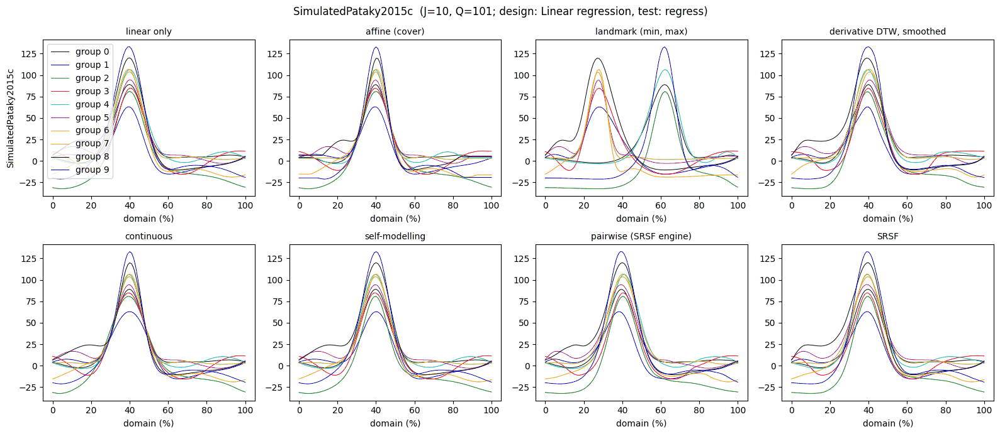

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.822       0.231      0.6
landmark (min, max)               5.795       0.324      0.0
derivative DTW, smoothed          1.126       0.110      0.6
continuous                        0.737       0.045      1.8
self-modelling                    0.951       0.036      3.6
pairwise (SRSF engine)            1.144       0.152      4.5
SRSF                              1.120       0.076      2.5


In [50]:
y, g, out = analyse('SimulatedPataky2015c')

## SimulatedTwoLocalMax

Two groups of curves with two local maxima whose relative heights differ between groups
(two-sample t-test).

**Auto-tuning.** This is the peak-correspondence problem: when the dominant peak switches between
groups, global-extremum landmarks pair the wrong peaks and elastic methods may align peak 1 of one
group with peak 2 of the other. No objective-function criterion distinguishes the two solutions;
correspondence must come from prior knowledge (which peak is which) or from a landmark table that
a user can edit. The automatic detection should therefore return *all* prominent peaks with
their prominences (as `peaks_as_landmarks` does) and flag observations whose peak count differs
from the majority, instead of silently taking the global maximum.

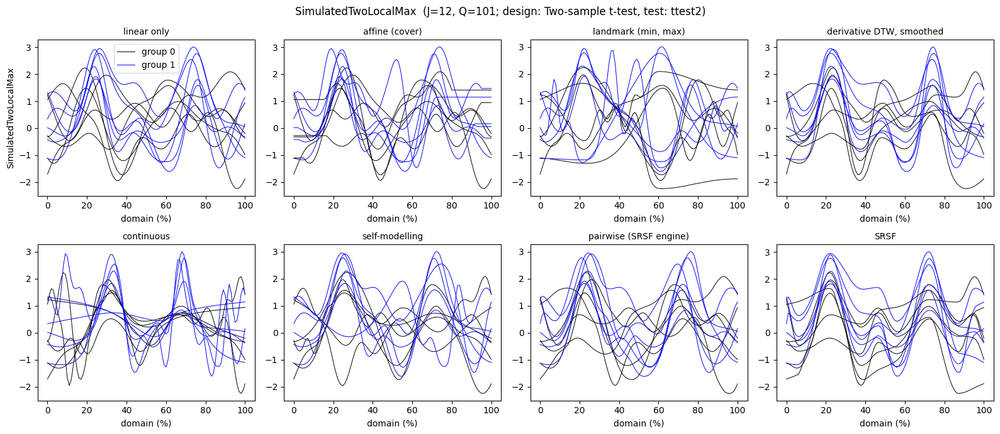

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.849       0.400      0.7
landmark (min, max)               1.637       0.430      0.0
derivative DTW, smoothed          0.829       0.182      0.8
continuous                        0.598       0.459      3.5
self-modelling                    0.946       0.356      7.4
pairwise (SRSF engine)            0.873       0.131      6.8
SRSF                              0.802       0.166      3.1


In [51]:
y, g, out = analyse('SimulatedTwoLocalMax')

## SmallSampleLargePosNegEffects

Eight curves in two groups with large opposite-sign differences (two-sample t-test).

**Design.** With J = 8 and strong group differences the pooled template lies between two quite
different shapes and represents neither group; the warps then partly encode "which group am I
in", and the two-sample test on displacement fields becomes a test of the template's
compromise rather than of timing. This is the situation in which group-specific templates are
most tempting and most dangerous (they remove exactly the effect under test). The safest
design-aware behaviour is diagnostic: report the distance of each group's mean from the template
and warn when the groups are far apart relative to their spread.

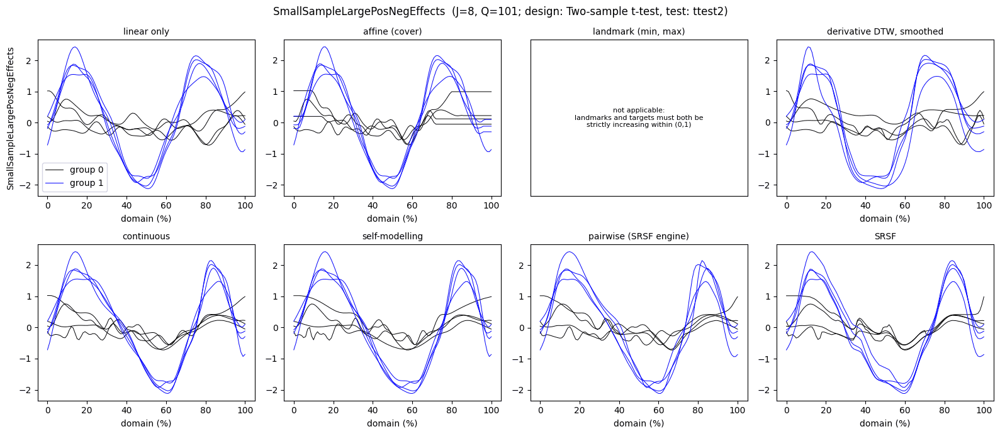

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.801       0.400      0.3
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          1.028       0.232      0.5
continuous                        0.689       0.274      2.4
self-modelling                    0.733       0.381      4.1
pairwise (SRSF engine)            0.781       0.201      2.6
SRSF                              0.702       0.224      1.9


In [52]:
y, g, out = analyse('SmallSampleLargePosNegEffects')

## SpeedGRF

Vertical ground reaction forces at 60 walking speeds (linear regression), sharply defined double
hump.

**Auto-tuning.** J = 60 curves with clear, consistent features: the method rankings are stable,
and this is the kind of data on which automatic tuning is meaningful. The tunable quantities are
few and observable: the elasticity penalty (`lam='auto'` here is dominated by the loading/unloading
slopes and leaves the warps small), the number of continuous-registration basis functions
(choose by the residual plateau), and the DTW smoothing width (choose as a multiple of the
correlation length of the curves, estimated from their autocorrelation). All three could be set
from the data with a one-line rule and reported.

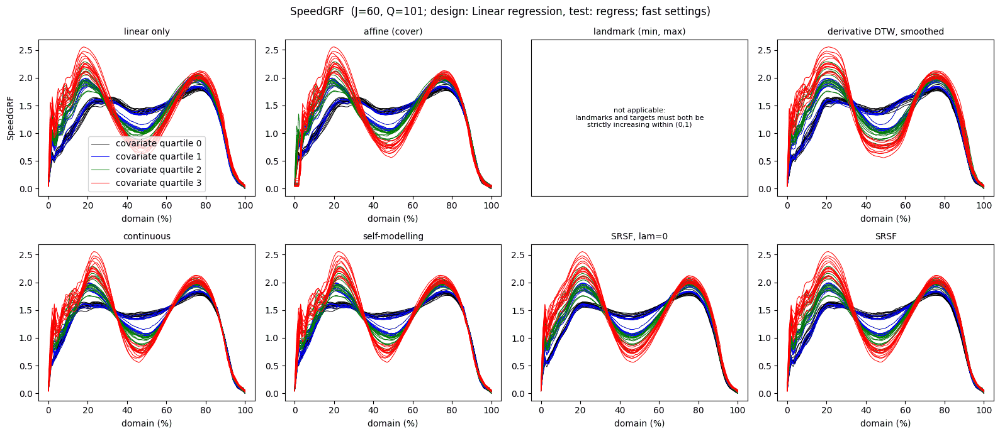

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.879       0.028      1.3
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          1.177       0.087      2.5
continuous                        0.596       0.085      7.2
self-modelling                    0.609       0.088     16.0
SRSF, lam=0                       0.819       0.120      7.8
SRSF                              0.848       0.115      8.0


In [53]:
y, g, out = analyse('SpeedGRF')

## SpeedGRFcategorical

The **SpeedGRF** curves with speed coded as three categories (one-way ANOVA).

**Design.** Unbalanced or unequal-variance groups bias a pooled template towards the larger or
more homogeneous group; group-balanced templates (the Karcher mean of group means) remove that
bias without removing group timing differences from the warps, and are the one design-aware
choice that does *not* pre-empt any downstream test. This is the minimal, defensible use of design
information at the registration stage.

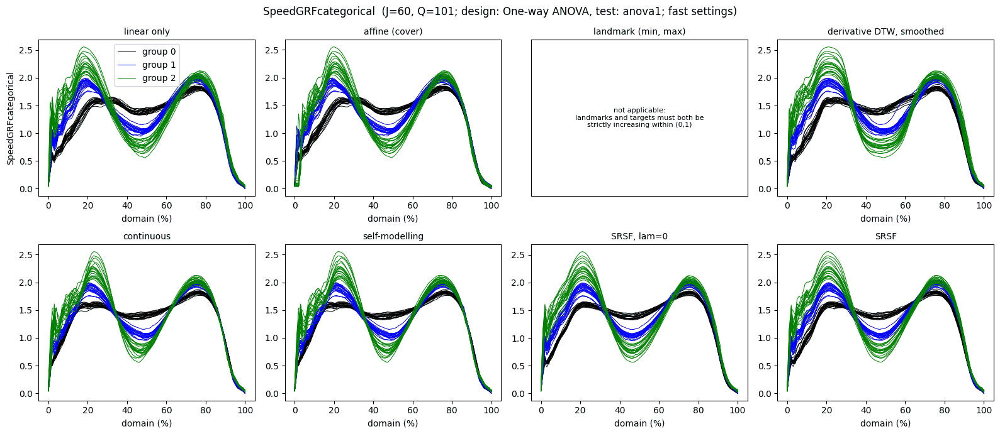

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.879       0.028      1.3
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          1.177       0.087      2.4
continuous                        0.596       0.085      7.5
self-modelling                    0.609       0.088     16.0
SRSF, lam=0                       0.819       0.120      7.9
SRSF                              0.848       0.115      7.9


In [54]:
y, g, out = analyse('SpeedGRFcategorical')

## SpeedGRFcategoricalRM

The categorical speed design with subjects as a repeated-measures factor (one-way RM ANOVA).

No implications beyond those of **SpeedGRFcategorical** and **SPM1D_ANOVA2ONERM_2x2**; this is
the real-data case for the hierarchical (subject × condition) warp decomposition.

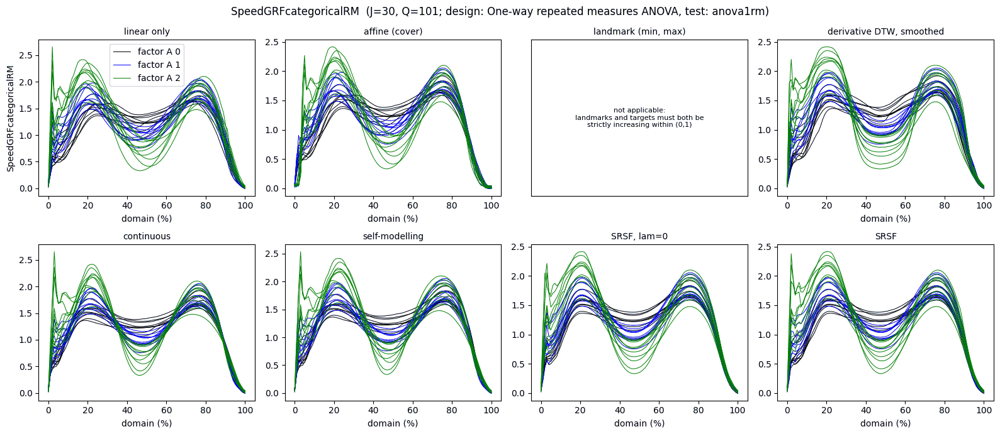

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.820       0.058      1.7
landmark (min, max)                   -           -      0.0
derivative DTW, smoothed          1.111       0.086      1.8
continuous                        0.653       0.078      4.5
self-modelling                    0.702       0.080     10.7
SRSF, lam=0                       0.820       0.102      7.1
SRSF                              0.841       0.067      7.7


In [55]:
y, g, out = analyse('SpeedGRFcategoricalRM')

## Weather

Daily mean temperature over the year at 35 Canadian weather stations in four climate regions
(one-way ANOVA), Q = 365.

**Auto-tuning.** The `continuous` panel shows the pinching artefact described under **Random**
on real data: with six basis functions and the default penalty, every station is forced
through two common crossing points. The domain is periodic: 31 December is adjacent to 1 January, but every method
here fixes the warp end points and cannot rotate the year. For periodic data the first
registration step should be a circular shift (a shift registration on the circle), and the
elastic warp should be applied to the shifted curves with the seam placed at a data-chosen
position (the coldest day, say). Periodicity is detectable automatically (the first and last
values agree to within the noise level for every curve), so this is a case where the *type* of
registration, not only its parameters, can be chosen from the data. Q = 365 also makes the
dynamic programme about ten times slower than at Q = 101; automatic down-sampling to a coarser
grid for the alignment, followed by evaluation of the warp on the full grid, would be a natural
speed rule.

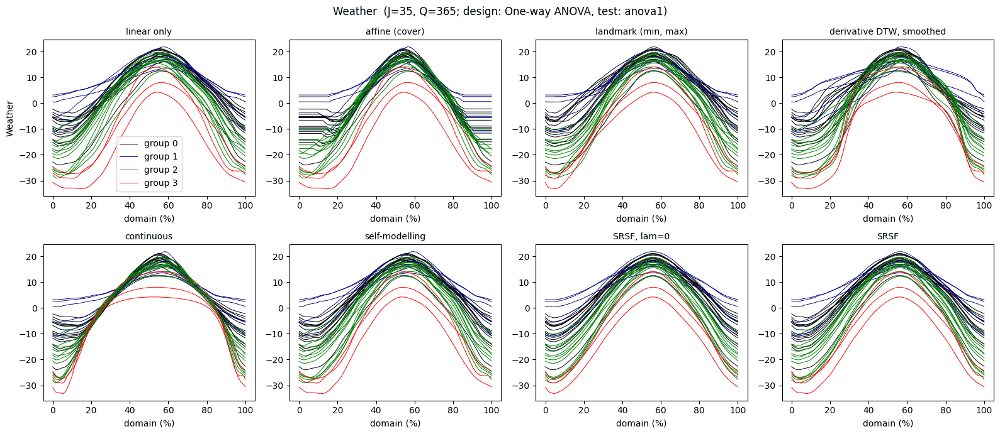

method                        SSE ratio  max |disp|  seconds
linear only                       1.000       0.000      0.0
affine (cover)                    0.771       0.200      1.9
landmark (min, max)               0.871       0.117      0.0
derivative DTW, smoothed          0.925       0.188     27.4
continuous                        0.434       0.210      4.5
self-modelling                    0.930       0.056      9.1
SRSF, lam=0                       0.863       0.113     96.4
SRSF                              0.883       0.076    100.8


In [56]:
y, g, out = analyse('Weather')

## Summary of implications

**Automated parameter tuning** cannot be driven by the residual alone: on every one of the 38
featureless simulated datasets the residual falls under every elastic method, most under the
method with the most distorting warps. Tuning is realistic for a small set of observable quantities — the
elasticity penalty (already `lam='auto'`), the DTW smoothing width (from the curves' correlation
length), the number of parametric basis functions (from a residual plateau), per-component
standardisation for multivariate input, periodicity detection, and real-time versus normalised
time for ragged input — and should always be preceded by a *registrability* screen (surrogate
comparison or extremum-consistency check), because every method improves its objective on pure
noise. Choices that depend on the research question (which peak corresponds to which, whether a
covariate's timing effect is signal or nuisance, whether coordinates are a curve or separate
signals) cannot be automated and should be exposed as explicit, recorded decisions.

**Design information** can enter registration in three ways with increasing risk: (1)
group-balanced templates, which remove sample-composition bias without removing any effect
(safe); (2) hierarchical or paired templates that respect nesting, pairing or repeated measures,
which put subject-level timing where it belongs but require the matching mixed-effects timing
analysis; (3) condition- or covariate-specific templates, which move the effect under test out of
one domain (amplitude or timing) into the other and therefore pre-empt the analysis. Because the
registration determines what the subsequent tests can see, design-dependent registration should
be implemented, if at all, together with the analysis it is meant to serve (as in joint
registration-and-analysis models), and the result object should record which effects the
registration has absorbed.